# SteamScope：课程报告综合总结

本 Notebook 是 `Ultimate_Game_Insights` 项目的阶段性汇总。前面 6 个 Notebook 已经完成了从数据集理解、大表处理策略、清洗与特征工程，到市场结构、玩家反馈、标签定位的完整分析流程。

本 Notebook 不再展开新的复杂分析，而是把前面的结果整理成适合课程报告使用的叙事结构：

1. 为什么这个数据集适合“大数据处理分析”课程项目；
2. 项目使用了哪些数据处理方法和工具；
3. Steam 游戏市场结构有什么特点；
4. 玩家反馈与热度指标呈现什么规律；
5. 标签和类型如何反映市场定位；
6. 当前分析的局限性；
7. 后续可以如何扩展到简单推荐系统。

本 Notebook 的所有说明文字使用中文，图表标题和坐标轴仍尽量使用英文，以避免中文字体显示问题。

## 1. 环境与项目资源检查

报告综合 Notebook 依赖前面 Notebook 生成的 summary CSV 和 figures。大型 Parquet 文件不需要提交到 GitHub，但在本地如果存在，可以用于补充核对。

本节先检查关键文件是否存在，确保报告引用的内容可追溯。

In [1]:
from pathlib import Path
import json
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, Image

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed directory:", PROCESSED_DIR)
print("Figures directory:", FIGURES_DIR)

Project root: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights
Processed directory: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed
Figures directory: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures


In [2]:
required_files = [
    "data/processed/large_table_processing_benchmark.csv",
    "data/processed/steam_data_quality_report.csv",
    "data/processed/steam_reviews_popularity_metric_summary.csv",
    "data/processed/steam_reviews_popularity_snapshot_summary.csv",
    "data/processed/steam_tag_positioning_summary.csv",
    "data/processed/steam_tag_niche_high_feedback_candidates.csv",
    "data/processed/steam_tag_cooccurrence_pairs_top.csv",
    "data/processed/steam_indie_tag_lift_summary.csv",
    "figures/01_steam_dataset_file_size_and_rows.png",
    "figures/04_processing_time_by_tool_and_task.png",
    "figures/10_free_vs_paid_market_share.png",
    "figures/18_snapshot_market_structure_comparison.png",
    "figures/19_attention_metrics_log_distributions.png",
    "figures/29_feedback_popularity_correlation_heatmap.png",
    "figures/32_tag_competition_vs_positive_feedback.png",
    "figures/35_tag_cooccurrence_jaccard_heatmap.png",
]

resource_check = []
for rel in required_files:
    path = PROJECT_ROOT / rel
    resource_check.append({
        "file": rel,
        "exists": path.exists(),
        "size_kb": path.stat().st_size / 1024 if path.exists() else np.nan
    })
resource_check = pd.DataFrame(resource_check)
display(resource_check)

missing_resources = resource_check.loc[~resource_check["exists"], "file"].tolist()
if missing_resources:
    print("Warning: 以下资源缺失，可能需要先运行前面的 Notebook：")
    for item in missing_resources:
        print("-", item)
else:
    print("All key report resources are available.")

,file,exists,size_kb
0,data/processed/large_table_processing_benchmar...,True,0.808
1,data/processed/steam_data_quality_report.csv,True,1.434
2,data/processed/steam_reviews_popularity_metric...,True,0.344
3,data/processed/steam_reviews_popularity_snapsh...,True,0.336
4,data/processed/steam_tag_positioning_summary.csv,True,64.893
5,data/processed/steam_tag_niche_high_feedback_c...,True,6.785
6,data/processed/steam_tag_cooccurrence_pairs_to...,True,18.403
7,data/processed/steam_indie_tag_lift_summary.csv,True,29.996
8,figures/01_steam_dataset_file_size_and_rows.png,True,64.099
9,figures/04_processing_time_by_tool_and_task.png,True,66.373


All key report resources are available.


## 2. 项目问题与 Notebook 叙事线

本项目不是简单堆叠图表，而是围绕两个核心问题展开：

1. 在 Steam 上，什么样的游戏更容易获得玩家关注？
2. Steam 游戏市场在 2024 到 2025 之间发生了什么变化？

为了回答这两个问题，项目采用 Notebook 主线，把大规模表格数据一步一步处理成可解释的课程报告证据。

In [3]:
notebook_storyline = pd.DataFrame([
    {
        "notebook": "01_steam_dataset_overview.ipynb",
        "role": "数据集介绍与大数据合理性",
        "main_question": "为什么这个数据集适合大数据处理课程项目？",
        "main_outputs": "文件规模、行数、字段结构、核心列缺失率"
    },
    {
        "notebook": "02_large_table_processing_strategy.ipynb",
        "role": "大表处理工具与策略",
        "main_question": "如何高效、可复现地处理约 1.7GB 的 Steam CSV？",
        "main_outputs": "pandas / duckdb / polars 对比、Parquet 策略"
    },
    {
        "notebook": "03_steam_data_cleaning_and_features.ipynb",
        "role": "数据清洗与特征工程",
        "main_question": "如何把原始 CSV 转换成可靠的分析数据资产？",
        "main_outputs": "清洗报告、特征 Parquet、样例 CSV"
    },
    {
        "notebook": "04_steam_market_structure_analysis.ipynb",
        "role": "Steam 市场结构",
        "main_question": "Steam 游戏市场由哪些供给结构组成？",
        "main_outputs": "发行趋势、价格结构、平台结构、长尾结构"
    },
    {
        "notebook": "05_steam_reviews_popularity_analysis.ipynb",
        "role": "玩家反馈与热度",
        "main_question": "哪些属性与玩家关注和反馈有关？",
        "main_outputs": "评论、好评率、推荐、峰值在线、相关性"
    },
    {
        "notebook": "06_steam_tag_genre_positioning_analysis.ipynb",
        "role": "标签、类型与市场定位",
        "main_question": "标签和类型如何描述竞争格局与定位？",
        "main_outputs": "标签竞争、共现、genre-tag 矩阵、Indie lift"
    },
    {
        "notebook": "07_report_synthesis.ipynb",
        "role": "报告综合总结",
        "main_question": "如何把前面结果整理成课程报告叙事？",
        "main_outputs": "方法总结、主要发现、局限性、后续方向"
    },
])
display(notebook_storyline)

,notebook,role,main_question,main_outputs
0,01_steam_dataset_overview.ipynb,数据集介绍与大数据合理性,为什么这个数据集适合大数据处理课程项目？,文件规模、行数、字段结构、核心列缺失率
1,02_large_table_processing_strategy.ipynb,大表处理工具与策略,如何高效、可复现地处理约 1.7GB 的 Steam CSV？,pandas / duckdb / polars 对比、Parquet 策略
2,03_steam_data_cleaning_and_features.ipynb,数据清洗与特征工程,如何把原始 CSV 转换成可靠的分析数据资产？,清洗报告、特征 Parquet、样例 CSV
3,04_steam_market_structure_analysis.ipynb,Steam 市场结构,Steam 游戏市场由哪些供给结构组成？,发行趋势、价格结构、平台结构、长尾结构
4,05_steam_reviews_popularity_analysis.ipynb,玩家反馈与热度,哪些属性与玩家关注和反馈有关？,评论、好评率、推荐、峰值在线、相关性
5,06_steam_tag_genre_positioning_analysis.ipynb,标签、类型与市场定位,标签和类型如何描述竞争格局与定位？,标签竞争、共现、genre-tag 矩阵、Indie lift
6,07_report_synthesis.ipynb,报告综合总结,如何把前面结果整理成课程报告叙事？,方法总结、主要发现、局限性、后续方向


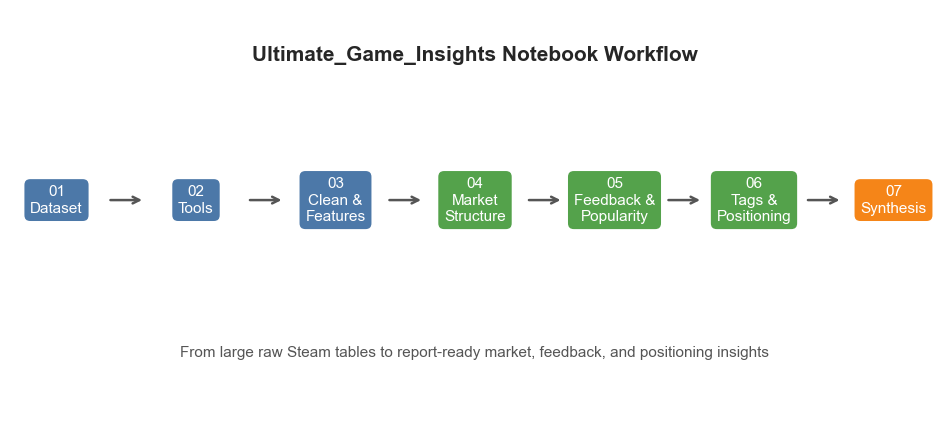

Saved: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/38_report_notebook_workflow.png


In [4]:
# 生成一个简单的 Notebook 流程图，作为报告中方法部分的总览图。
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.axis("off")
steps = ["01\nDataset", "02\nTools", "03\nClean &\nFeatures", "04\nMarket\nStructure", "05\nFeedback &\nPopularity", "06\nTags &\nPositioning", "07\nSynthesis"]
xs = np.linspace(0.05, 0.95, len(steps))
y = 0.55
for i, (x, label) in enumerate(zip(xs, steps)):
    color = "#4C78A8" if i < 3 else "#54A24B" if i < 6 else "#F58518"
    ax.text(x, y, label, ha="center", va="center", fontsize=11, color="white",
            bbox=dict(boxstyle="round,pad=0.45", facecolor=color, edgecolor="white", linewidth=1.5))
    if i < len(steps) - 1:
        ax.annotate("", xy=(xs[i+1] - 0.055, y), xytext=(x + 0.055, y),
                    arrowprops=dict(arrowstyle="->", color="#555555", lw=1.8))
ax.text(0.5, 0.88, "Ultimate_Game_Insights Notebook Workflow", ha="center", fontsize=15, weight="bold")
ax.text(0.5, 0.18, "From large raw Steam tables to report-ready market, feedback, and positioning insights", ha="center", fontsize=11, color="#555555")
workflow_path = FIGURES_DIR / "38_report_notebook_workflow.png"
plt.savefig(workflow_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", workflow_path)

## 3. 数据集与大数据处理价值

本项目使用 Kaggle 的 Steam Games Dataset 2025。数据文件总量约 1.7GB，包含 2024 和 2025 两个时间快照，字段类型混合，既有数值字段，也有类别、多标签、时间和文本字段。

从课程角度看，这个数据集的价值不只在于“游戏主题有趣”，更在于它适合展示大规模表格数据处理流程：文件检查、分列读取、工具对比、Parquet 转换、清洗检查、特征工程和可视化分析。

In [5]:
# 从 README/project_brief 中记录的事实整理数据集规模表。
dataset_scale = pd.DataFrame([
    {"file": "games_march2025_cleaned.csv", "approx_size_mb": 447, "approx_rows": 89619, "role": "主分析文件"},
    {"file": "games_march2025_full.csv", "approx_size_mb": 450, "approx_rows": 94949, "role": "2025 完整字段文件"},
    {"file": "games_may2024_cleaned.csv", "approx_size_mb": 403, "approx_rows": 83647, "role": "快照对比文件"},
    {"file": "games_may2024_full.csv", "approx_size_mb": 405, "approx_rows": 87807, "role": "2024 完整字段文件"},
])
dataset_scale["approx_size_gb"] = dataset_scale["approx_size_mb"] / 1024
display(dataset_scale)

total_size_gb = dataset_scale["approx_size_mb"].sum() / 1024
print(f"Approximate total raw CSV size: {total_size_gb:.2f} GB")

,file,approx_size_mb,approx_rows,role,approx_size_gb
0,games_march2025_cleaned.csv,447,89619,主分析文件,0.437
1,games_march2025_full.csv,450,94949,2025 完整字段文件,0.439
2,games_may2024_cleaned.csv,403,83647,快照对比文件,0.394
3,games_may2024_full.csv,405,87807,2024 完整字段文件,0.396


Approximate total raw CSV size: 1.67 GB


这些文件不适合直接提交到 GitHub。项目采用“数据可再生”的方式管理：原始数据通过 Kaggle 链接和下载说明获取，大型 Parquet 文件通过 Notebook 重新生成，小型 summary CSV、图表和 Notebook 用于提交和展示。

## 4. 大表处理工具与策略总结

Notebook 02 对 `pandas`、`duckdb` 和 `polars` 做了实用对比。这个部分对应课程中“大量级表格处理工具”的内容，但它不是项目主线，而是为后续分析选择合适的数据处理策略。

核心结论是：保留原始 CSV，使用列选择减少读取压力，把反复使用的核心字段转换成 Parquet；日常展示可用 pandas，SQL 式聚合可用 duckdb，高性能 DataFrame 操作可用 polars。

,tool,task,elapsed_sec,rss_before_mb,rss_after_mb,rss_delta_mb,rows,columns,output_file,output_size_mb
0,pandas,selected_column_read,1.516,268.050,484.160,216.110,89618,17,NaN,NaN
1,duckdb,selected_column_read,1.043,487.810,703.670,215.860,89618,17,NaN,NaN
2,polars,selected_column_read,0.162,703.670,823.580,119.910,89618,17,NaN,NaN
3,pandas,yearly_aggregation_from_csv,1.334,823.890,933.730,109.840,27,6,NaN,NaN
4,duckdb,yearly_aggregation_from_csv,0.935,933.730,944.020,10.280,27,6,NaN,NaN
5,polars,yearly_aggregation_from_csv,0.198,943.970,999.770,55.800,27,6,NaN,NaN
6,polars,csv_selected_columns_to_parquet,0.251,999.800,974.120,-25.670,89618,17,steam_march2025_selected.parquet,6.010
7,pandas,read_selected_parquet,0.156,977.910,"1,024.800",46.890,89618,17,NaN,NaN
8,duckdb,read_selected_parquet,0.104,"1,024.800","1,012.220",-12.580,89618,17,NaN,NaN
9,polars,read_selected_parquet,0.040,"1,012.250","1,031.390",19.140,89618,17,NaN,NaN


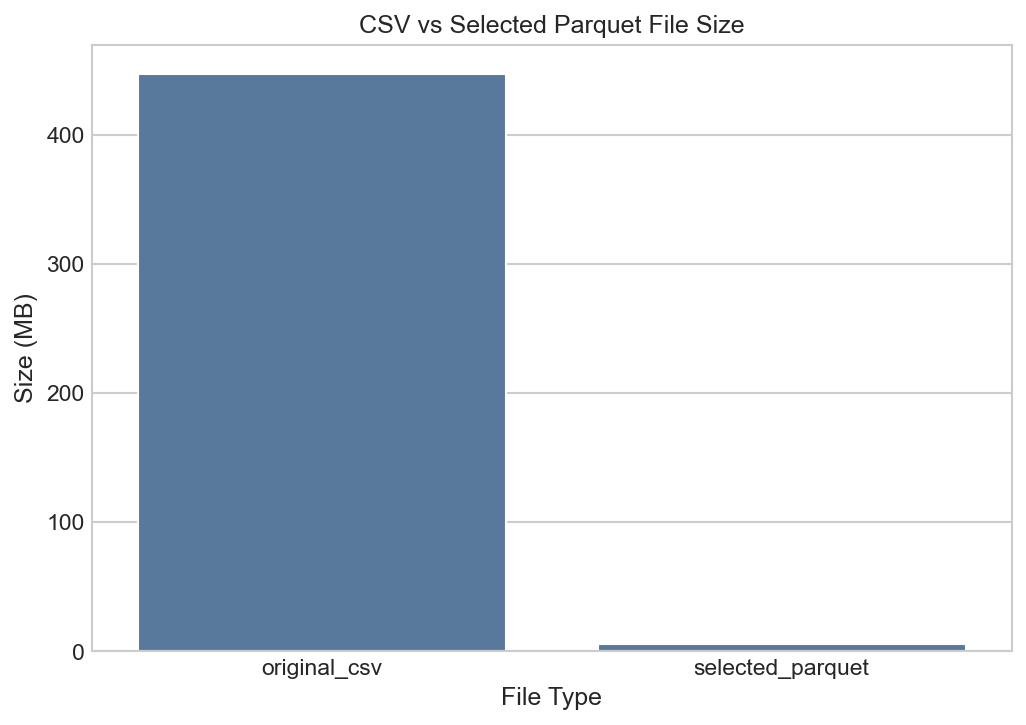

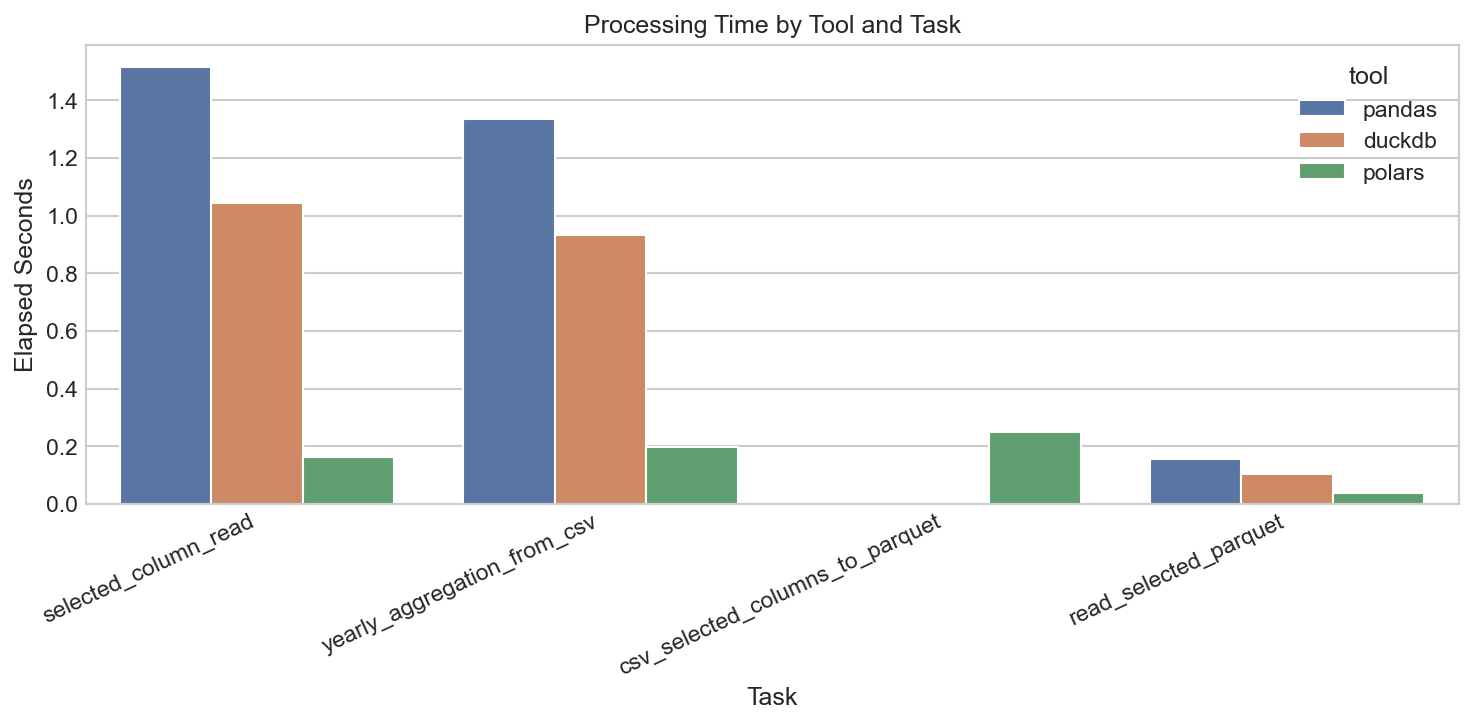

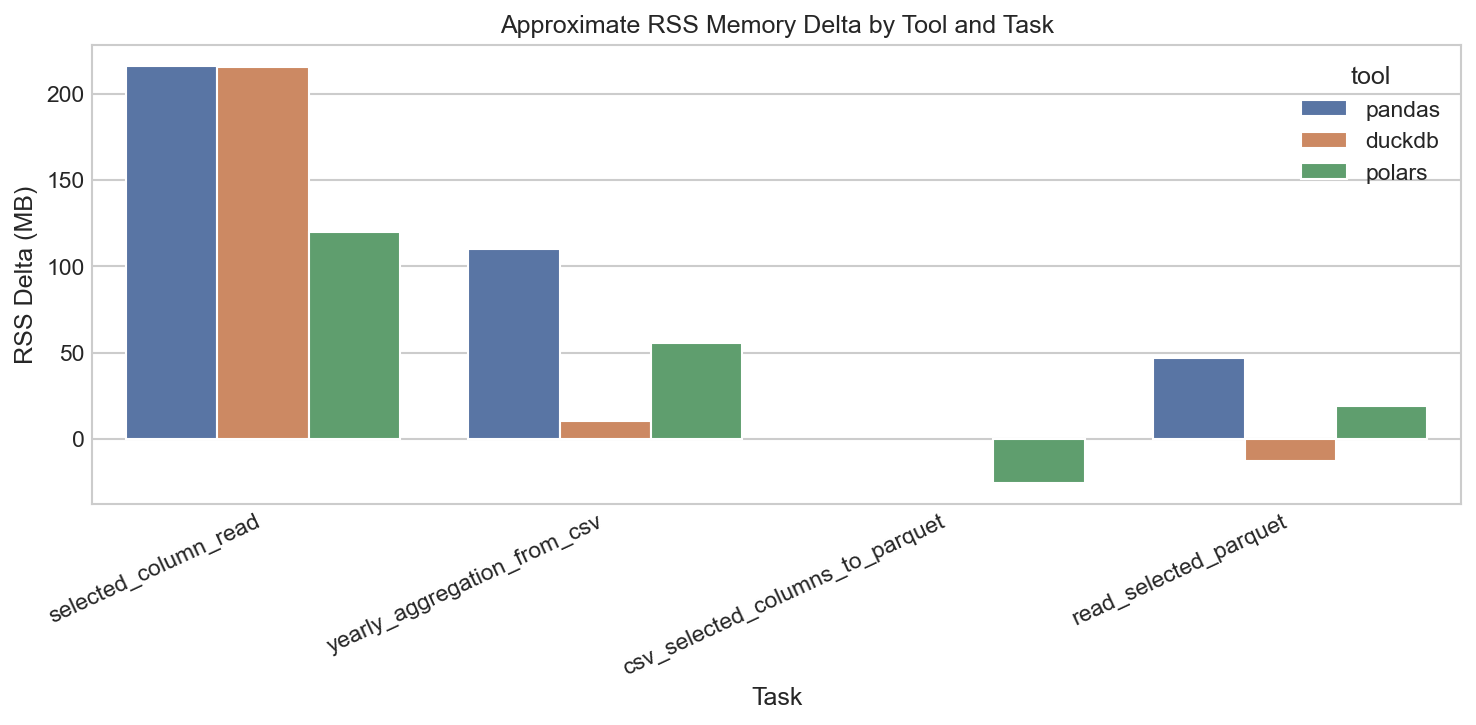

In [6]:
benchmark_path = PROCESSED_DIR / "large_table_processing_benchmark.csv"
if benchmark_path.exists():
    benchmark = pd.read_csv(benchmark_path)
    display(benchmark)
else:
    benchmark = pd.DataFrame()
    print("Benchmark file not found.")

selected_figures = [
    "03_csv_vs_selected_parquet_size.png",
    "04_processing_time_by_tool_and_task.png",
    "05_memory_delta_by_tool_and_task.png",
]
for fig_name in selected_figures:
    path = FIGURES_DIR / fig_name
    if path.exists():
        display(Image(filename=str(path)))

从工具策略看，本项目体现了“不是所有数据都要一次性完整读入内存”的思想。通过选择列、转换 Parquet 和按任务选择工具，可以在普通个人电脑上完成较大表格数据的处理和分析。

## 5. 数据清洗与特征工程总结

Notebook 03 将原始 Steam CSV 转换成可复用的分析数据资产。它完成了字段统一、缺失值检查、重复值检查、异常范围检查、日期解析、多标签字段解析和基础特征工程。

特别需要注意的是，Steam 数据中的某些百分比字段使用 `-1` 表示不可用值，因此 Notebook 03 将这类非法百分比转换为缺失值，避免后续分析把 `-1%` 当成真实比例。

,check,issue,affected_rows,note,missing_ratio
0,identifier,missing appid,0,NaN,NaN
1,identifier,duplicate appid,0,NaN,NaN
2,duplicates,duplicate full rows,0,NaN,NaN
3,missing_key_feature,appid,0,missing ratio recorded,0.000
4,missing_key_feature,name,0,missing ratio recorded,0.000
5,missing_key_feature,release_date,0,missing ratio recorded,0.000
6,missing_key_feature,release_year,0,missing ratio recorded,0.000
7,missing_key_feature,price,0,missing ratio recorded,0.000
8,missing_key_feature,is_free,0,missing ratio recorded,0.000
9,missing_key_feature,platform_count,0,missing ratio recorded,0.000


,item,value
0,Feature dataset rows,"89,618"
1,Feature dataset columns,63
2,Main feature file,data/processed/steam_march2025_features.parque...
3,Small sample file,data/processed/steam_march2025_features_sample...
4,Key engineered features,"release year, game age, platform count, review..."


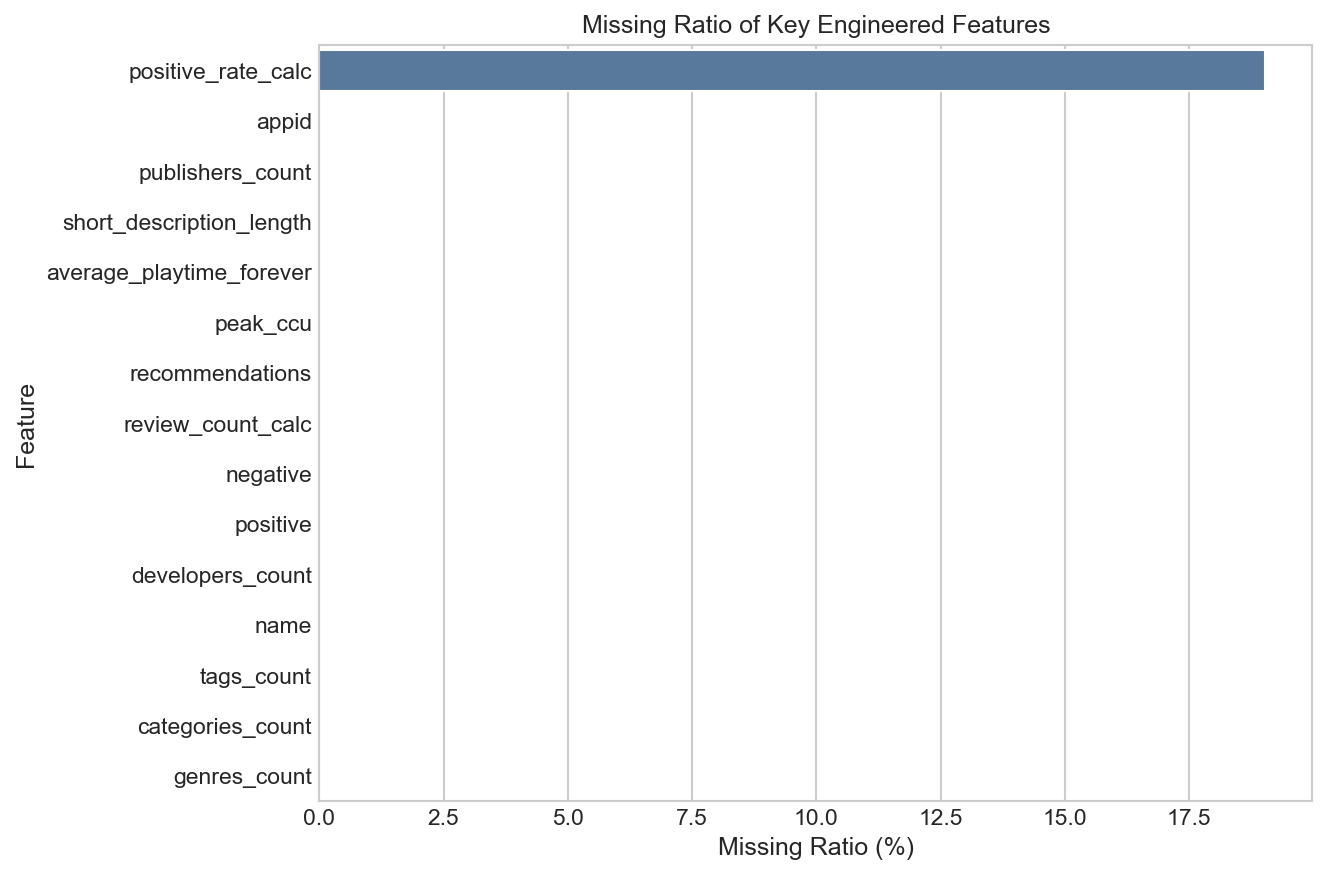

In [7]:
quality_path = PROCESSED_DIR / "steam_data_quality_report.csv"
if quality_path.exists():
    quality_report = pd.read_csv(quality_path)
    display(quality_report)
else:
    quality_report = pd.DataFrame()
    print("Quality report not found.")

feature_facts = pd.DataFrame([
    {"item": "Feature dataset rows", "value": "89,618"},
    {"item": "Feature dataset columns", "value": "63"},
    {"item": "Main feature file", "value": "data/processed/steam_march2025_features.parquet (ignored by GitHub)"},
    {"item": "Small sample file", "value": "data/processed/steam_march2025_features_sample.csv"},
    {"item": "Key engineered features", "value": "release year, game age, platform count, review count, positive rate, tag/genre counts, log popularity metrics"},
])
display(feature_facts)

path = FIGURES_DIR / "06_key_feature_missing_ratio.png"
if path.exists():
    display(Image(filename=str(path)))

这个步骤是后续所有分析的基础。项目没有把清洗过程隐藏在脚本里，而是通过 Notebook 展示每一步检查和处理，符合课程对“结果可验证”的要求。

## 6. Steam 市场结构主要发现

Notebook 04 从供给侧分析了 Steam 市场结构。它回答的是：Steam 上的游戏主要集中在哪些年份、价格层次、平台组合、类型和发行主体中？

这个部分帮助报告建立宏观背景：Steam 是一个高度扩张、内容供给长尾明显的平台生态。

,finding,value
0,Main analysis dataset,"89,618 games"
1,Valid release-year range,1997-2025
2,Peak release year in dataset,"2024, with 18,282 games"
3,Free game share,15.80%
4,Multi-platform game share,23.05%
5,Top genre/category/tag by coverage,Indie / Single-player / Indie
6,Snapshot unique AppIDs,"83,646 in May 2024; 89,618 in March 2025"


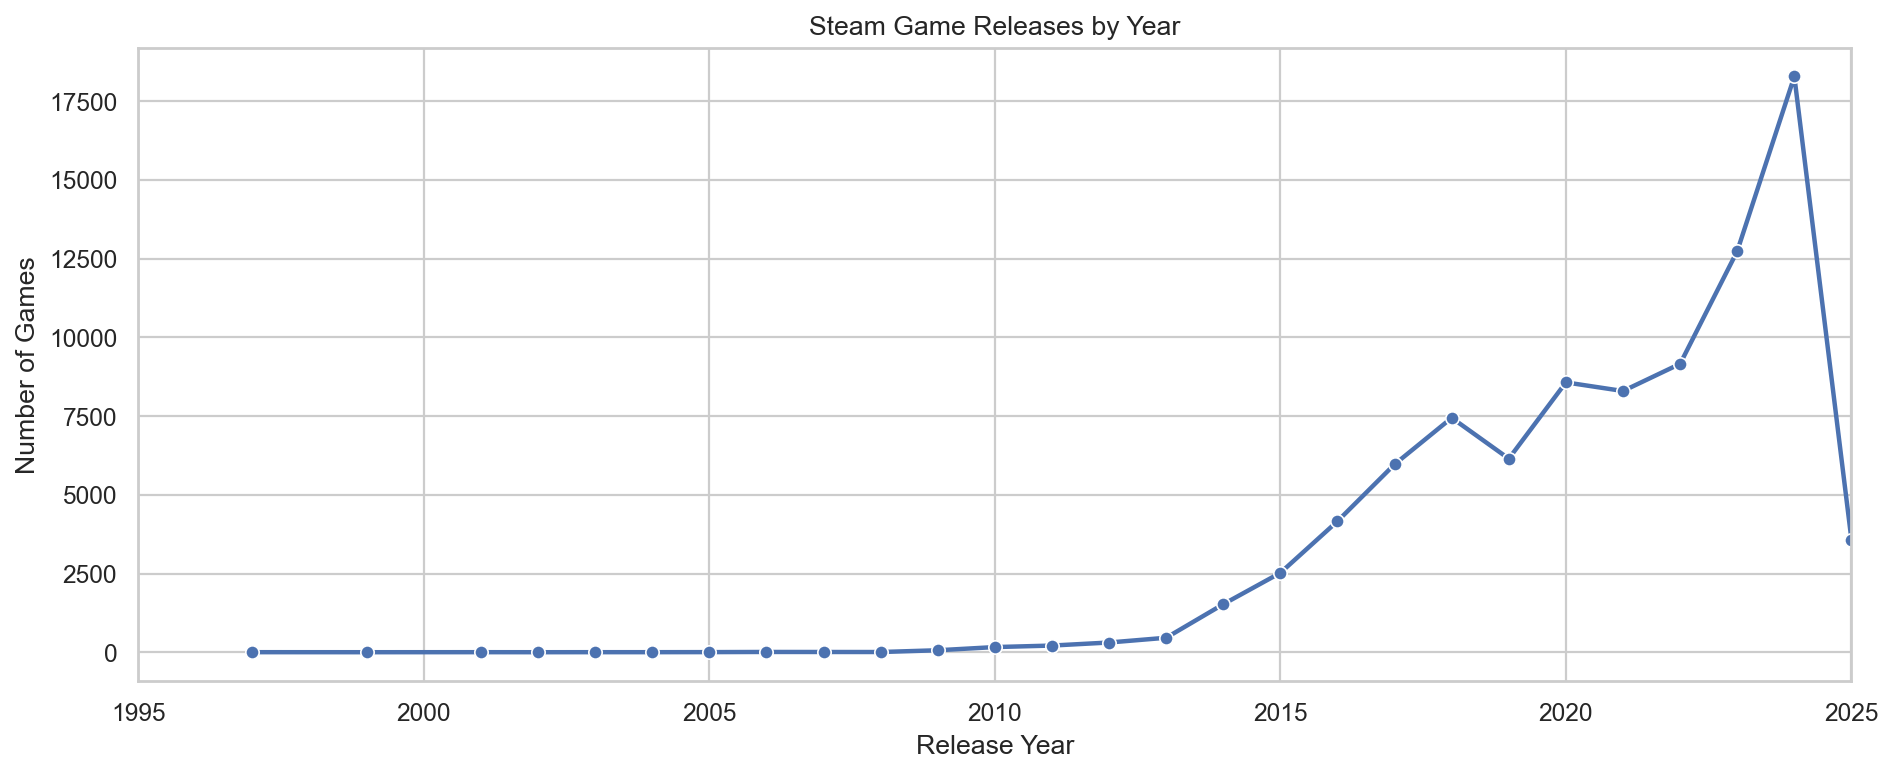

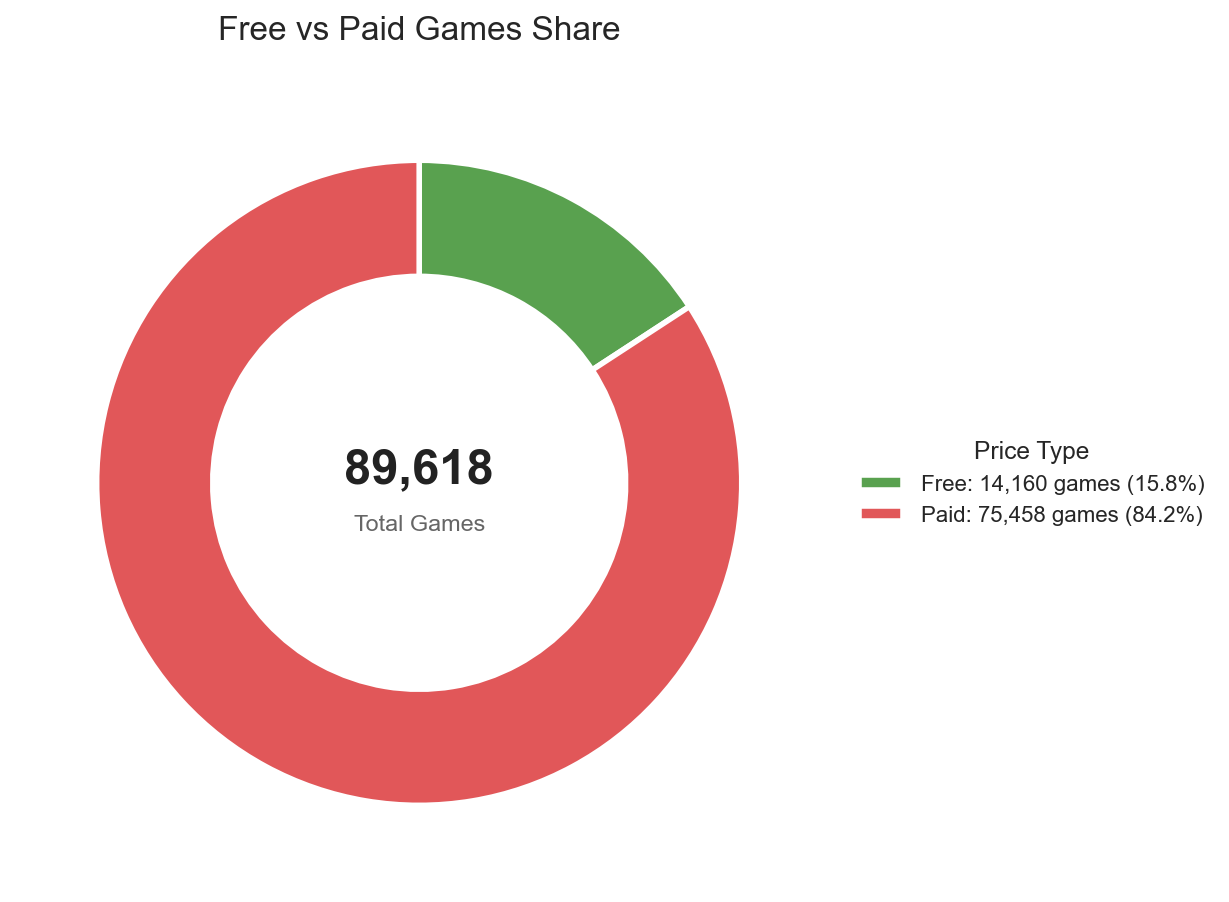

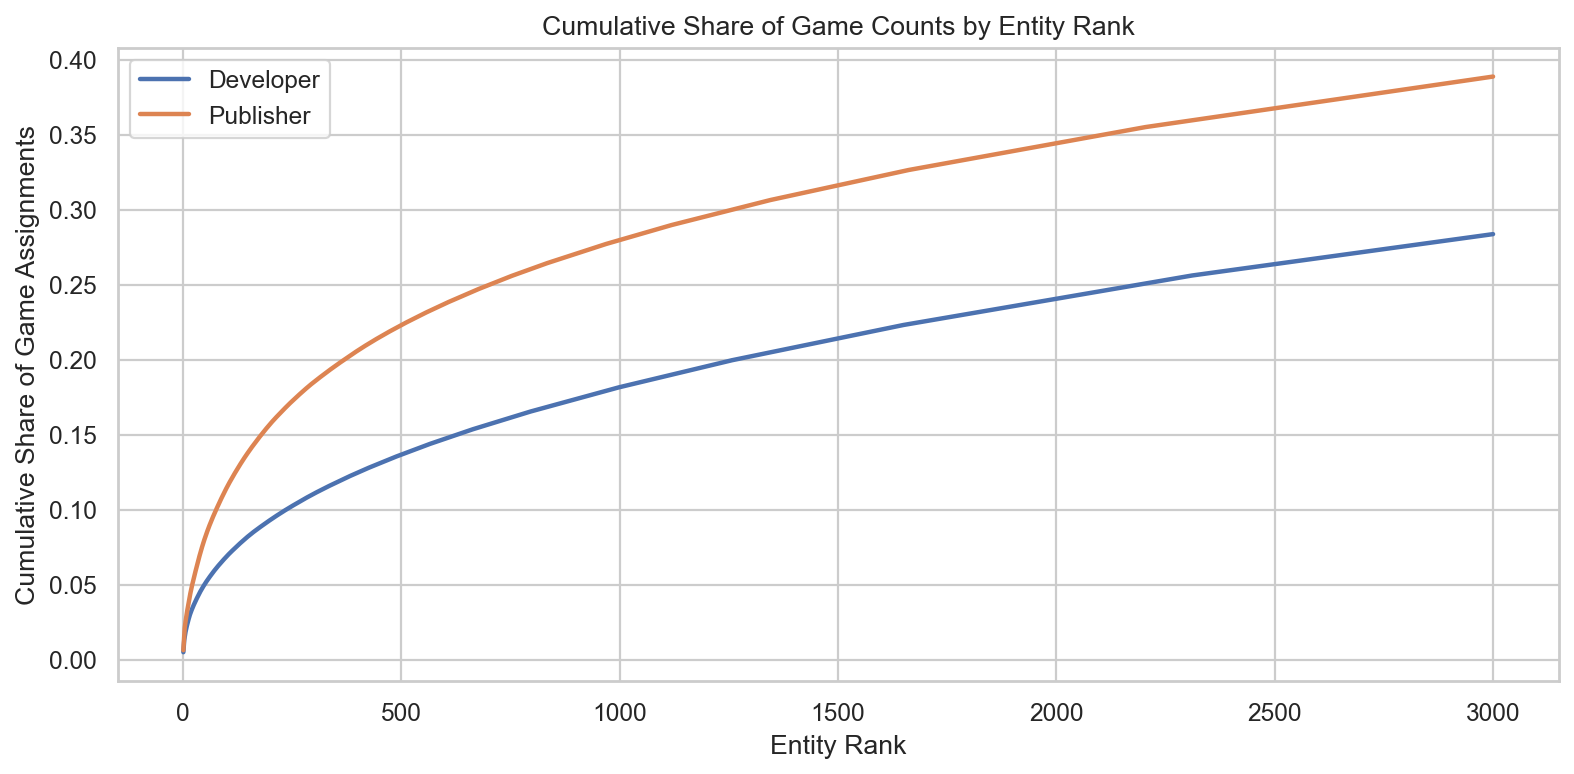

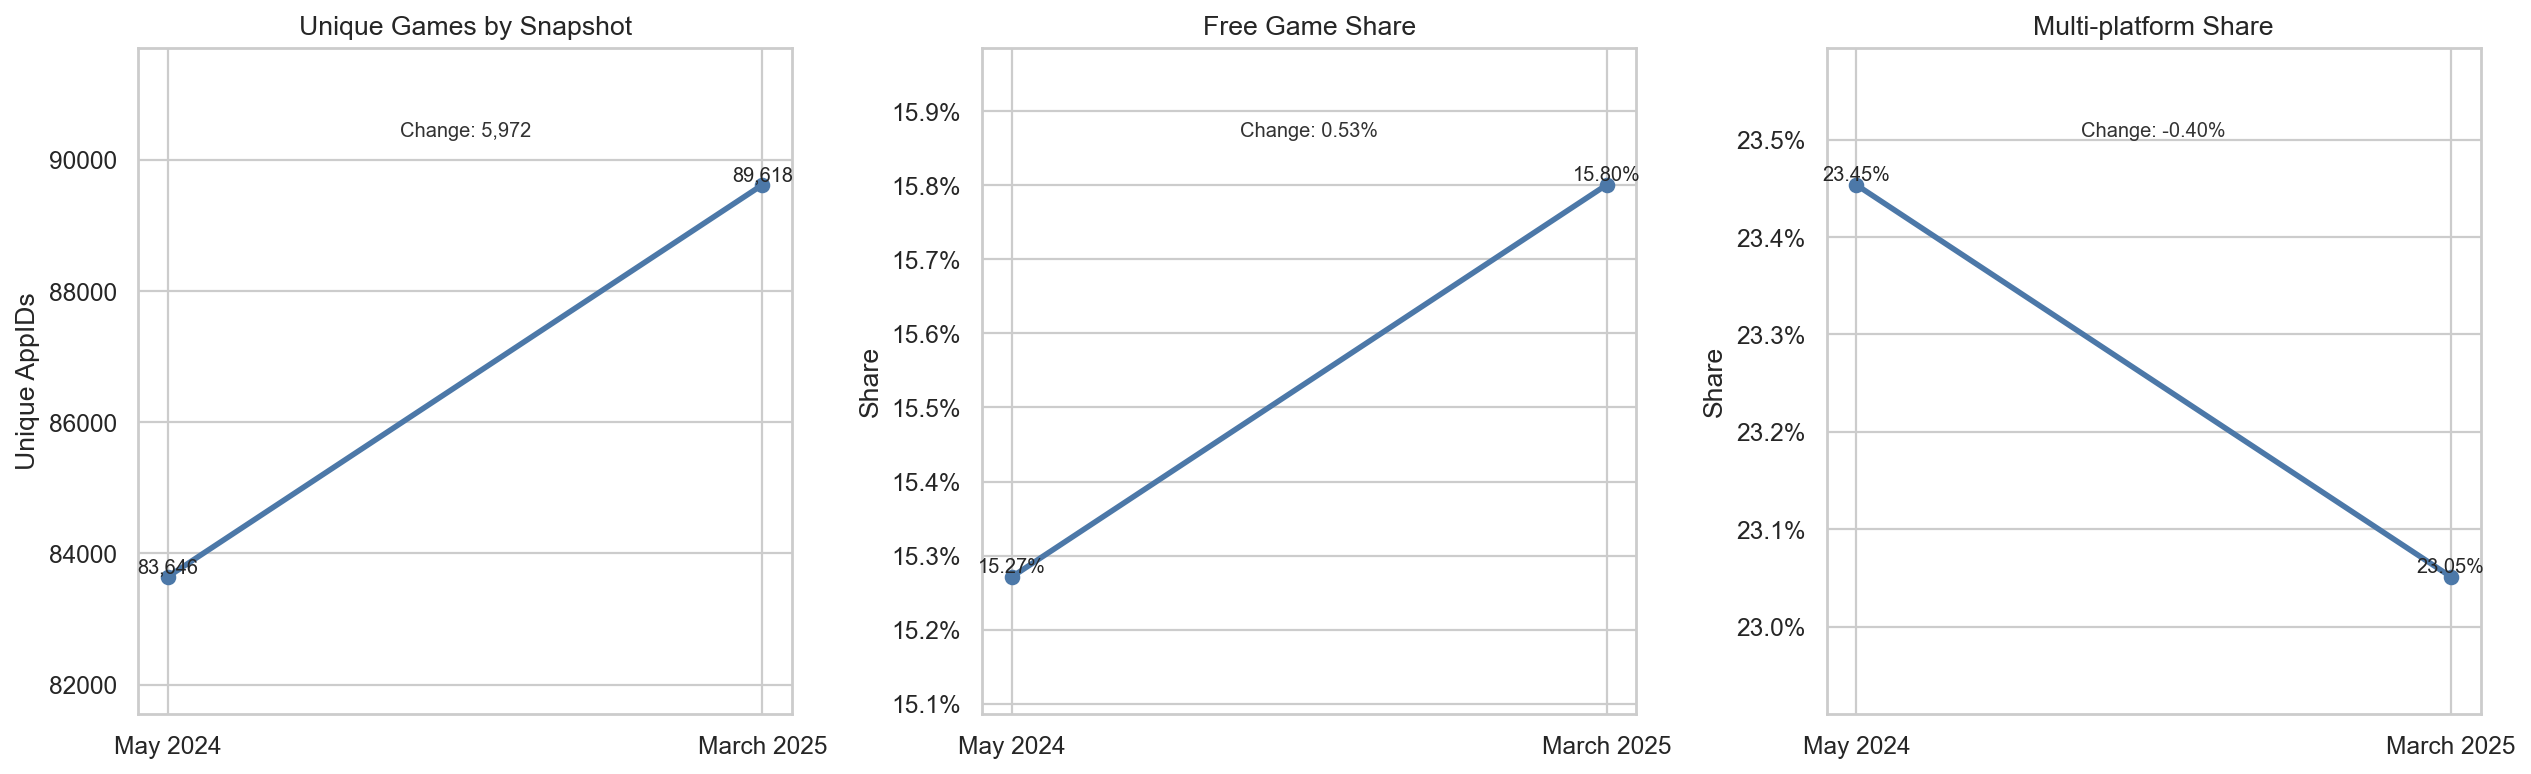

In [8]:
market_findings = pd.DataFrame([
    {"finding": "Main analysis dataset", "value": "89,618 games"},
    {"finding": "Valid release-year range", "value": "1997-2025"},
    {"finding": "Peak release year in dataset", "value": "2024, with 18,282 games"},
    {"finding": "Free game share", "value": "15.80%"},
    {"finding": "Multi-platform game share", "value": "23.05%"},
    {"finding": "Top genre/category/tag by coverage", "value": "Indie / Single-player / Indie"},
    {"finding": "Snapshot unique AppIDs", "value": "83,646 in May 2024; 89,618 in March 2025"},
])
display(market_findings)

for fig_name in [
    "07_market_release_trend_by_year.png",
    "10_free_vs_paid_market_share.png",
    "17_developer_publisher_long_tail_cumulative_share.png",
    "18_snapshot_market_structure_comparison.png",
]:
    path = FIGURES_DIR / fig_name
    if path.exists():
        display(Image(filename=str(path)))

市场结构部分的关键解释是：Steam 游戏供给高度集中在近年，并且开发商/发行商结构具有明显长尾。这意味着平台既有头部产品，也有大量中小作品；因此后续分析不能只看热门游戏，也要考虑长尾游戏的反馈和定位。

## 7. 玩家反馈与热度主要发现

Notebook 05 分析了评论数、好评率、推荐数、峰值在线人数和游玩时长。它区分了两个概念：

- 热度规模：有多少评论、推荐和在线人数；
- 反馈质量：玩家评价是否更正面。

这两个概念相关，但不是同一件事。

,metric,value
0,total_games,"89,618.000"
1,games_with_reviews,"72,563.000"
2,games_with_30plus_reviews,"33,358.000"
3,games_with_peak_ccu,"18,920.000"
4,games_with_playtime,"8,010.000"
5,median_review_count,13.000
6,mean_review_count,"1,479.699"
7,median_positive_rate_for_30plus_reviews,81.081
8,median_recommendations,0.000
9,median_peak_ccu,0.000


,snapshot,unique_appids,total_review_count,median_review_count,total_recommendations,median_recommendations,max_peak_ccu,median_positive_rate_30plus,free_game_share
0,March 2025,89618,132607623,13.000,90460506,0.000,1212356,81.081,0.158
1,May 2024,83646,124126364,15.000,83936893,0.000,1362469,80.952,0.153


,price,platform_count,game_age_years,genres_count,tags_count,review_count_calc_log1p,positive_rate_calc,recommendations_log1p,peak_ccu_log1p,average_playtime_forever_log1p,median_playtime_forever_log1p,attention_score_descriptive
price,1.000,0.061,0.015,-0.075,0.321,0.298,0.048,0.331,0.311,0.137,0.138,0.340
platform_count,0.061,1.000,0.142,0.014,0.051,0.138,0.074,0.122,0.101,0.094,0.093,0.146
game_age_years,0.015,0.142,1.000,-0.051,-0.039,0.446,-0.254,0.208,0.061,0.225,0.225,0.397
genres_count,-0.075,0.014,-0.051,1.000,0.132,0.002,-0.074,-0.028,-0.024,-0.004,-0.004,-0.004
tags_count,0.321,0.051,-0.039,0.132,1.000,0.560,0.171,0.278,0.275,0.161,0.160,0.523
review_count_calc_log1p,0.298,0.138,0.446,0.002,0.560,1.000,-0.069,0.603,0.520,0.412,0.411,0.953
positive_rate_calc,0.048,0.074,-0.254,-0.074,0.171,-0.069,1.000,0.046,0.076,-0.014,-0.014,-0.052
recommendations_log1p,0.331,0.122,0.208,-0.028,0.278,0.603,0.046,1.000,0.636,0.493,0.493,0.672
peak_ccu_log1p,0.311,0.101,0.061,-0.024,0.275,0.520,0.076,0.636,1.000,0.403,0.401,0.644
average_playtime_forever_log1p,0.137,0.094,0.225,-0.004,0.161,0.412,-0.014,0.493,0.403,1.000,1.000,0.417


,finding,value
0,Games with at least one review,"72,563"
1,Games with 30+ reviews,"33,358"
2,Review count distribution,"Median 13; mean about 1,479.70"
3,Median positive rate among 30+ review games,About 81.08%
4,Recommendations and peak CCU,Both median 0 in full dataset; highly long-tailed
5,Snapshot total reviews,"124,126,364 in May 2024; 132,607,623 in March ..."


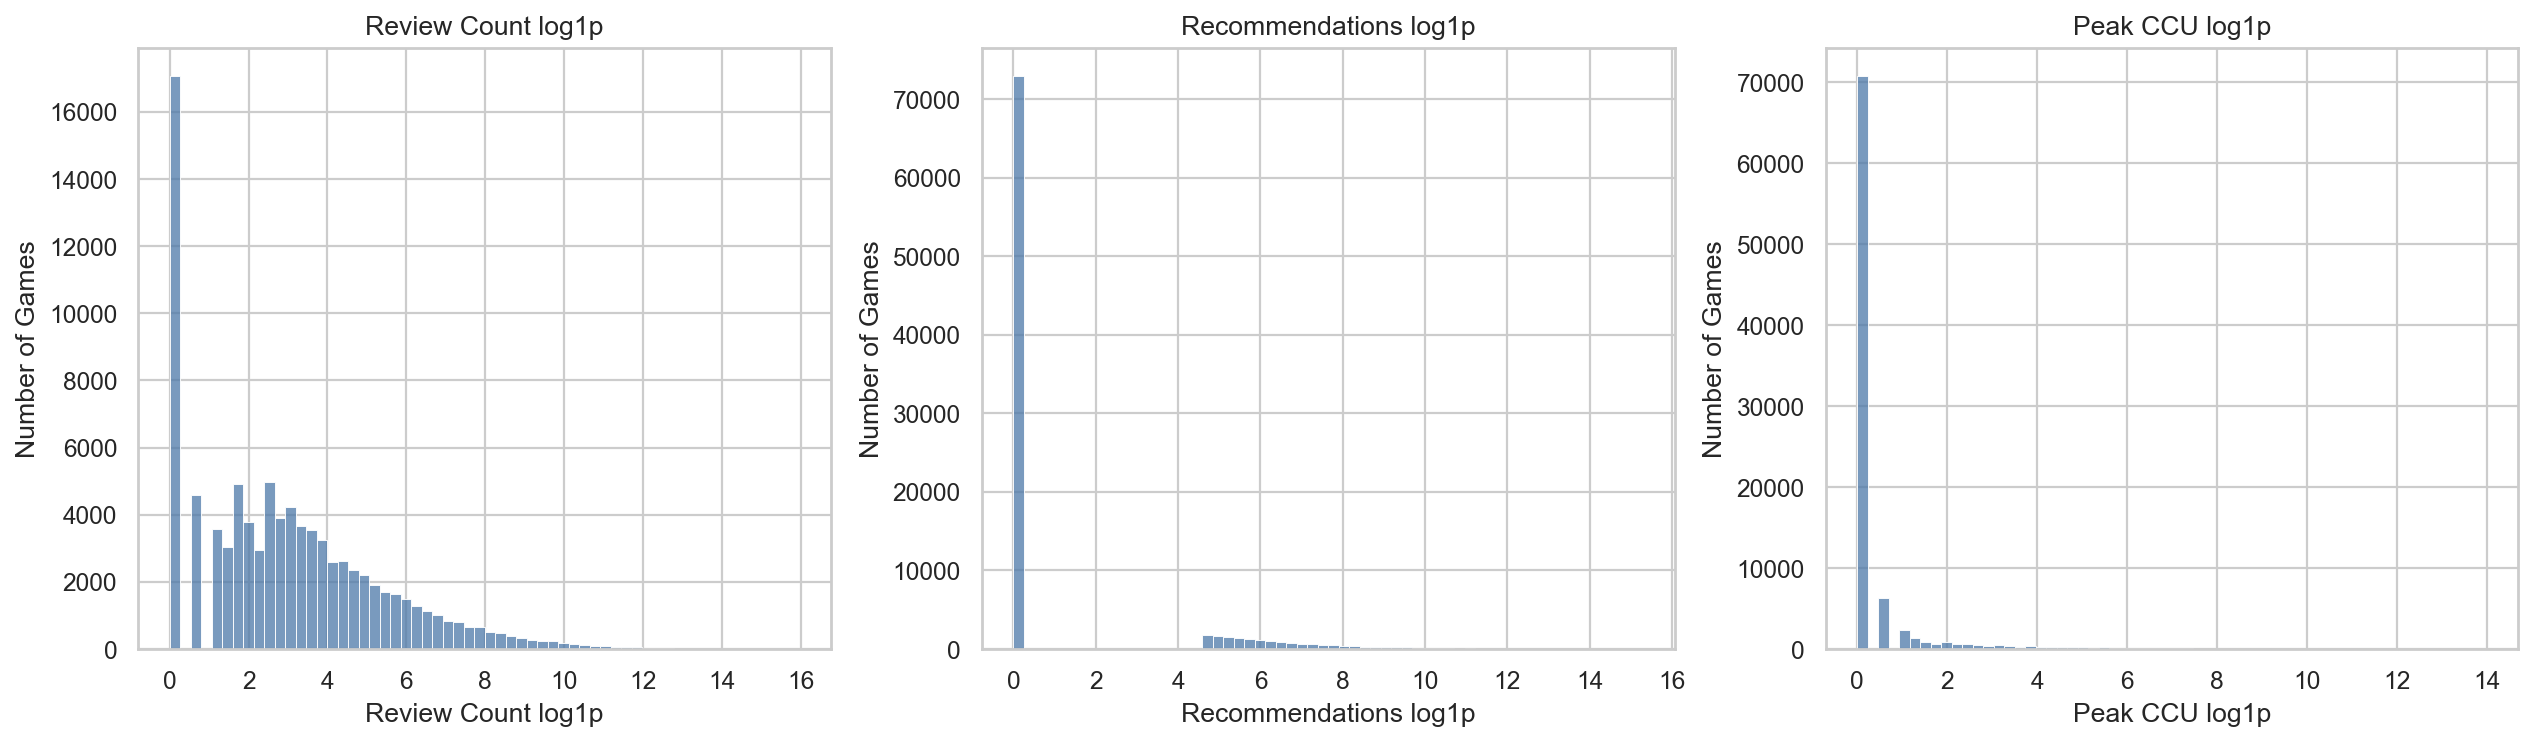

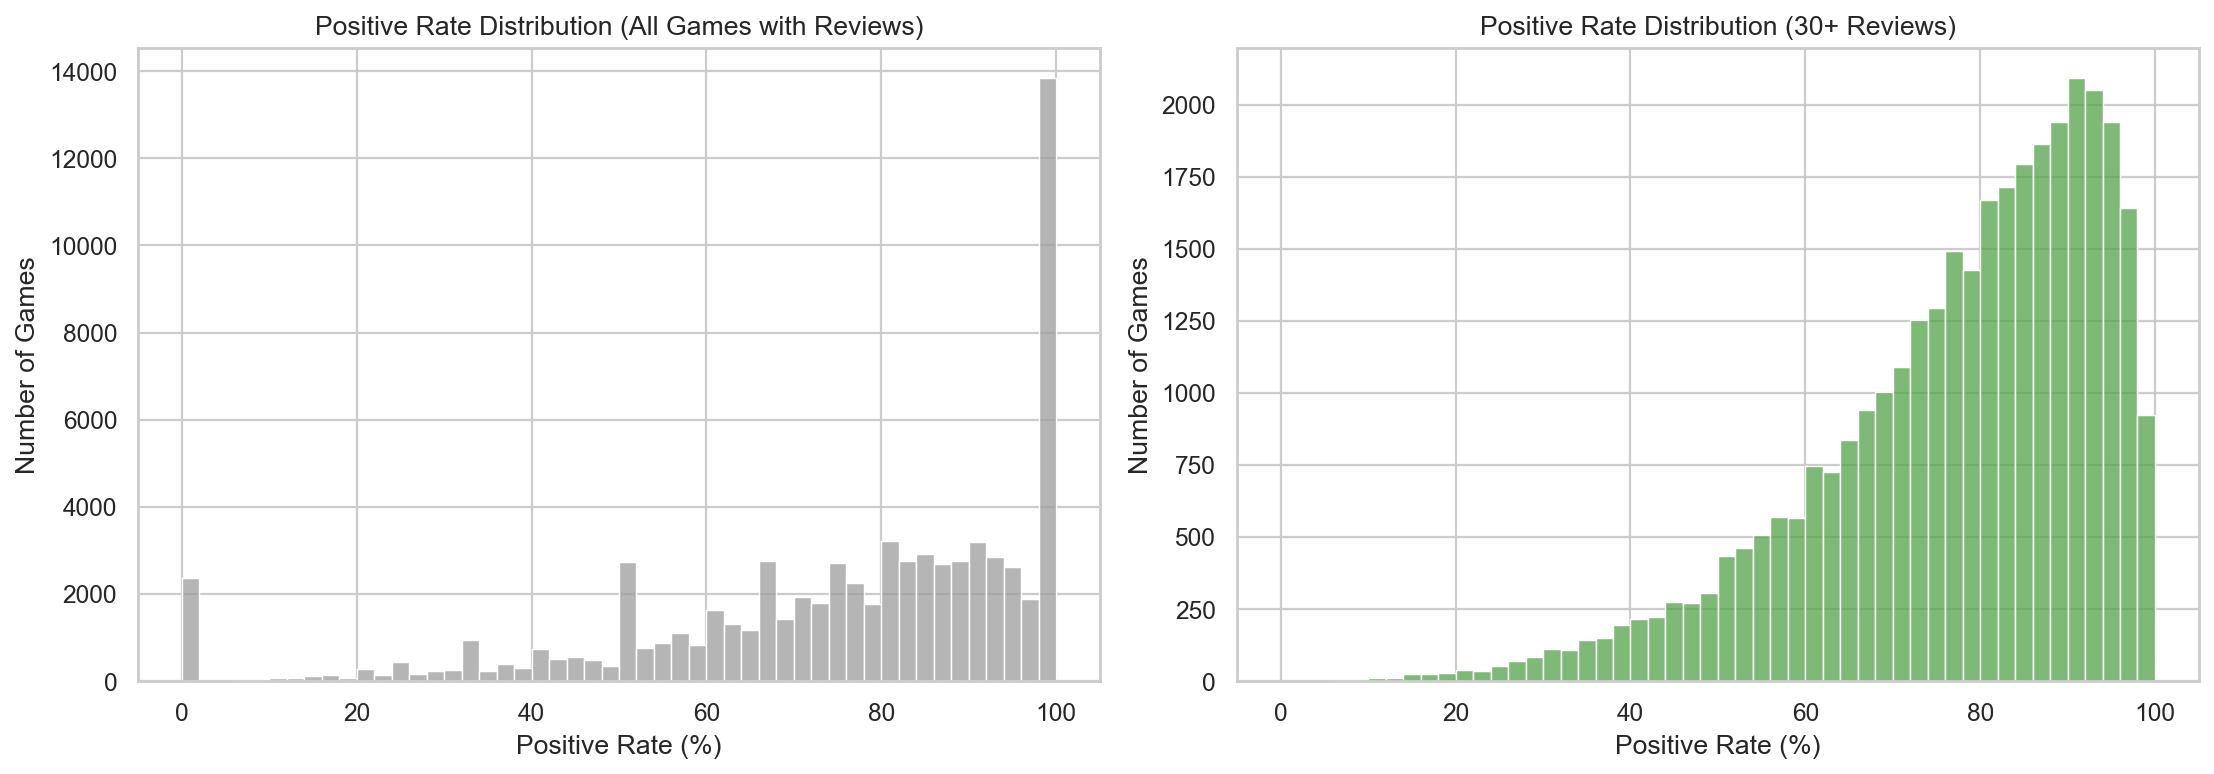

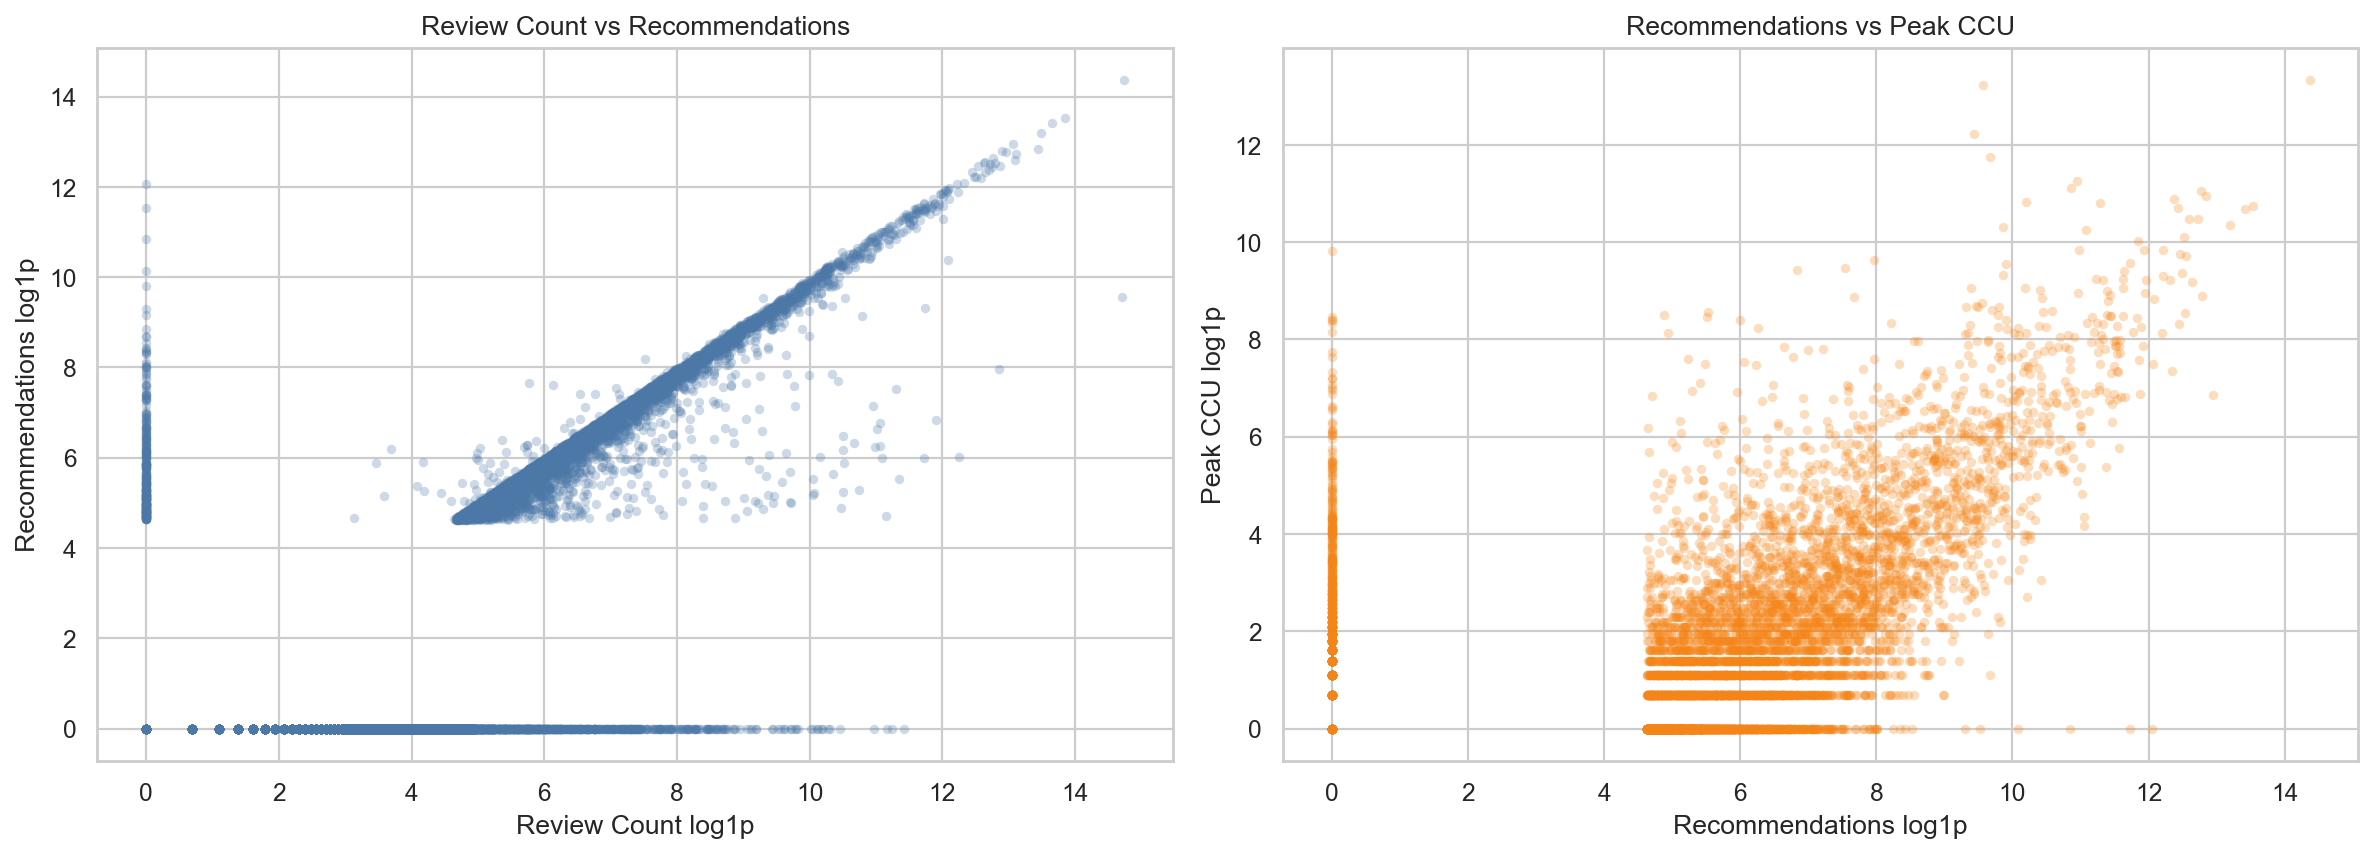

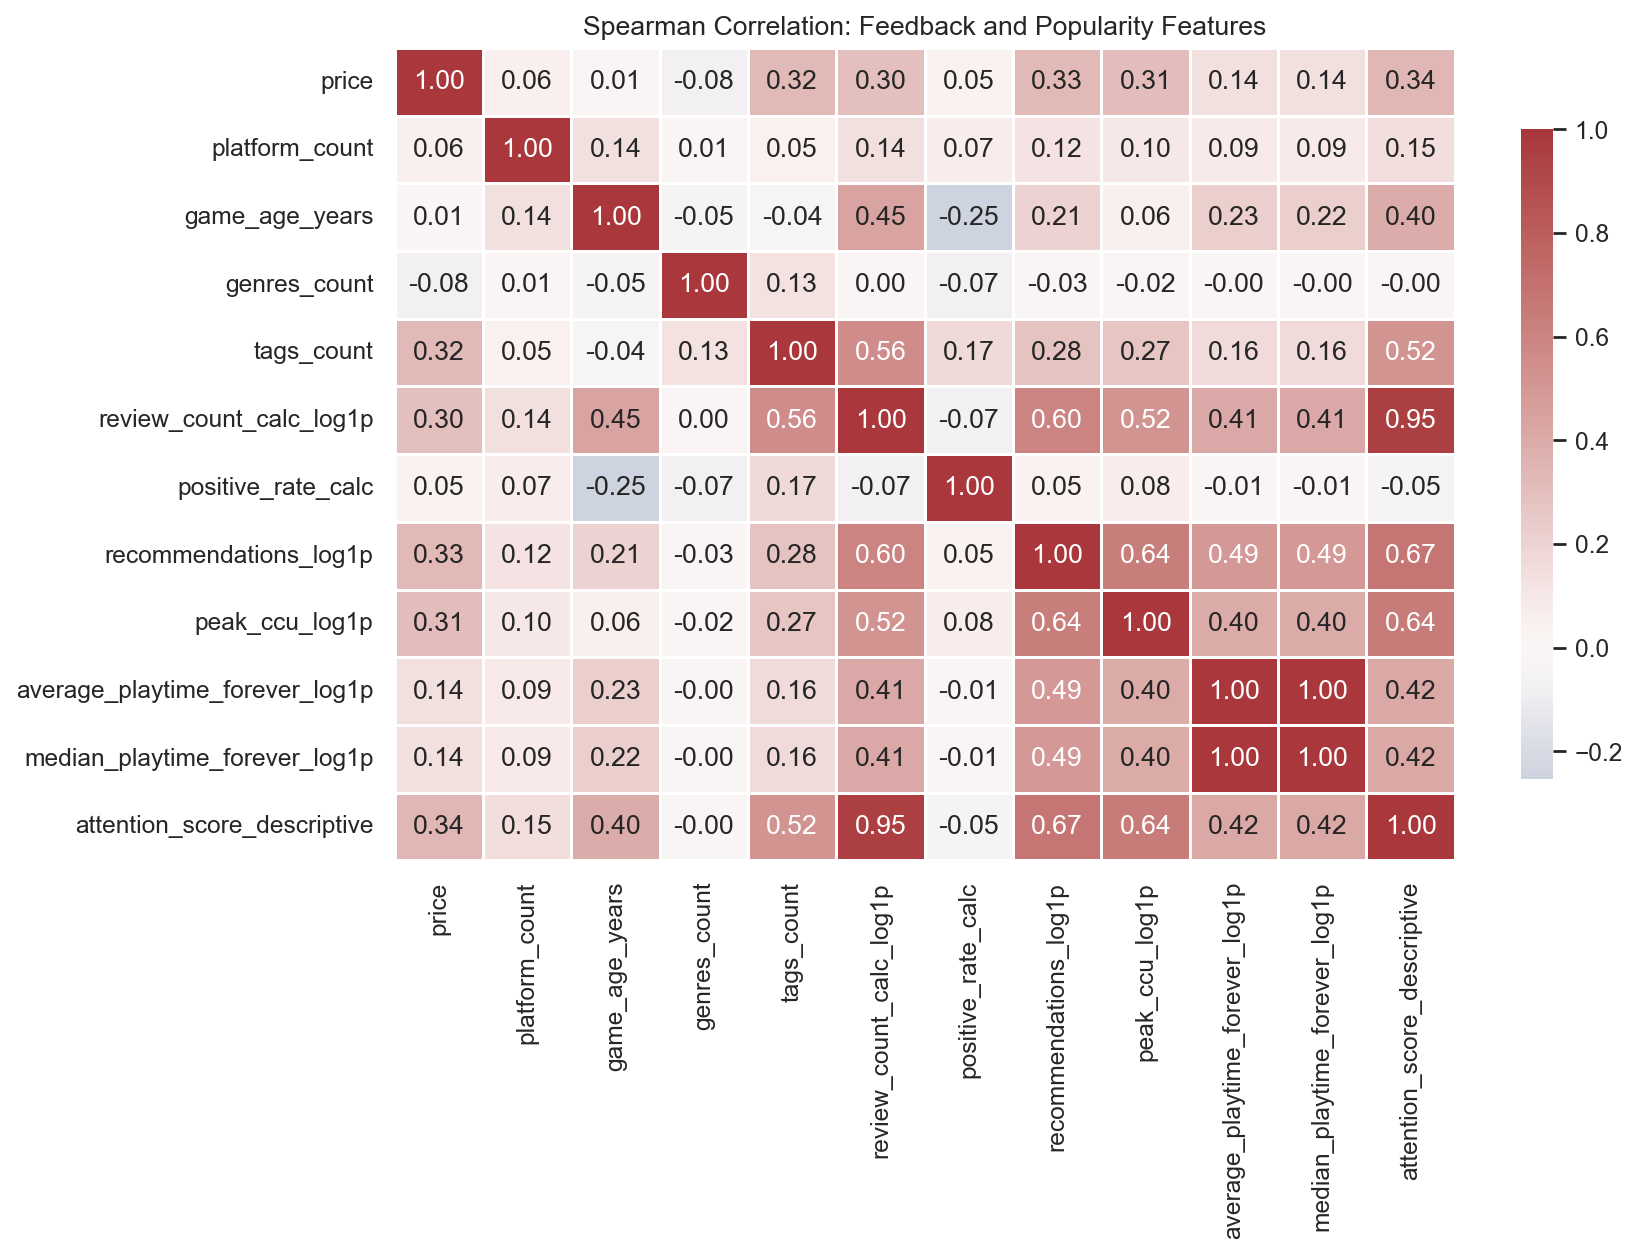

In [9]:
metric_summary_path = PROCESSED_DIR / "steam_reviews_popularity_metric_summary.csv"
snapshot_summary_path = PROCESSED_DIR / "steam_reviews_popularity_snapshot_summary.csv"
corr_path = PROCESSED_DIR / "steam_reviews_popularity_correlation.csv"

tables_to_show = []
if metric_summary_path.exists():
    metric_summary = pd.read_csv(metric_summary_path)
    display(metric_summary)
if snapshot_summary_path.exists():
    snapshot_summary = pd.read_csv(snapshot_summary_path)
    display(snapshot_summary)
if corr_path.exists():
    corr = pd.read_csv(corr_path, index_col=0)
    display(corr)

feedback_findings = pd.DataFrame([
    {"finding": "Games with at least one review", "value": "72,563"},
    {"finding": "Games with 30+ reviews", "value": "33,358"},
    {"finding": "Review count distribution", "value": "Median 13; mean about 1,479.70"},
    {"finding": "Median positive rate among 30+ review games", "value": "About 81.08%"},
    {"finding": "Recommendations and peak CCU", "value": "Both median 0 in full dataset; highly long-tailed"},
    {"finding": "Snapshot total reviews", "value": "124,126,364 in May 2024; 132,607,623 in March 2025"},
])
display(feedback_findings)

for fig_name in [
    "19_attention_metrics_log_distributions.png",
    "20_positive_rate_distribution_reliable_reviews.png",
    "22_popularity_proxy_relationships.png",
    "29_feedback_popularity_correlation_heatmap.png",
]:
    path = FIGURES_DIR / fig_name
    if path.exists():
        display(Image(filename=str(path)))

这部分最重要的发现是长尾：评论数、推荐数和峰值在线人数都被少数头部游戏显著拉高。平均值和中位数差距巨大，因此报告中应优先使用中位数、分位数和 log 变换图表，而不是只展示均值。

## 8. 标签、类型与市场定位主要发现

Notebook 06 把 Steam 标签视为市场定位语言，而不是普通类别字段。标签不仅描述类型，还描述玩法、题材、视角、情绪体验和玩家预期。

这个部分把项目从“市场有什么”推进到“游戏如何被定位”。

,tag,game_count,reliable_review_game_count,median_review_count,mean_review_count,median_positive_rate_30plus,median_recommendations,median_peak_ccu,mean_attention_score,free_share,median_price,median_release_year,game_share,competition_level
199,Indie,43408,20098,25.000,"1,106.581",80.658,0.000,0.000,0.076,0.097,4.990,"2,020.000",0.484,Very High
350,Singleplayer,42723,19573,23.000,"2,144.496",83.544,0.000,0.000,0.230,0.060,4.990,"2,022.000",0.477,Very High
17,Action,32315,14808,24.000,"3,199.940",79.642,0.000,0.000,0.173,0.094,4.990,"2,020.000",0.361,Very High
69,Casual,31832,13034,19.000,805.102,82.439,0.000,0.000,0.020,0.086,3.990,"2,021.000",0.355,Very High
23,Adventure,30772,15230,29.000,"2,190.479",81.395,0.000,0.000,0.218,0.077,4.990,"2,021.000",0.343,Very High
3,2D,22695,9694,20.000,989.555,86.553,0.000,0.000,0.099,0.061,4.990,"2,022.000",0.253,Very High
349,Simulation,15663,8371,36.000,"2,450.727",78.088,0.000,0.000,0.330,0.081,5.990,"2,021.000",0.175,Very High
377,Strategy,15465,7711,29.000,"2,768.615",78.788,0.000,0.000,0.282,0.092,4.990,"2,020.000",0.173,Very High
7,3D,14950,5382,15.000,992.943,81.538,0.000,0.000,0.031,0.061,4.990,"2,023.000",0.167,Very High
305,Puzzle,13923,6272,23.000,779.042,85.639,0.000,0.000,0.094,0.054,4.990,"2,021.000",0.155,Very High


,tag,game_count,reliable_review_game_count,median_review_count,mean_review_count,median_positive_rate_30plus,median_recommendations,median_peak_ccu,mean_attention_score,free_share,median_price,median_release_year,game_share,competition_level
0,Sokoban,555,180,16.000,135.467,93.952,0.000,0.000,-0.151,0.040,3.990,"2,022.000",0.006,Medium
1,Cozy,548,330,48.000,744.880,93.209,0.000,1.000,0.488,0.018,4.990,"2,024.000",0.006,Medium
2,Wholesome,419,255,55.000,727.136,92.405,0.000,0.000,0.417,0.010,4.990,"2,023.000",0.005,Medium
3,Electronic Music,97,31,15.000,307.113,90.247,0.000,0.000,-0.021,0.072,5.990,"2,022.000",0.001,Low
4,Faith,354,183,31.000,643.387,89.844,0.000,0.000,0.174,0.056,4.990,"2,022.000",0.004,Medium
5,LEGO,115,59,30.000,"2,789.861",89.274,0.000,0.000,0.641,0.061,5.990,"2,021.000",0.001,Low
6,Narrative,348,234,75.500,"1,362.463",89.271,0.000,0.000,0.510,0.055,9.990,"2,023.000",0.004,Medium
7,Nostalgia,204,134,155.500,"2,894.358",89.243,124.000,1.000,0.937,0.059,6.990,"2,021.000",0.002,Low
8,Touch-Friendly,233,178,241.000,"3,700.524",89.101,133.000,0.000,0.823,0.064,4.990,"2,017.000",0.003,Medium
9,Programming,404,198,27.500,660.267,89.091,0.000,0.000,0.251,0.069,7.990,"2,021.000",0.005,Medium


,tag_a,tag_b,cooccurrence_count,jaccard_similarity
0,Indie,Singleplayer,26699,0.449
1,Indie,Casual,20948,0.386
2,Singleplayer,2D,17542,0.366
3,Indie,Action,20027,0.360
4,Singleplayer,Adventure,19386,0.358
5,Singleplayer,Casual,19501,0.354
6,2D,Pixel Graphics,8942,0.350
7,Indie,Adventure,19057,0.346
8,Singleplayer,Action,18486,0.327
9,Action,Adventure,14581,0.301


,tag,indie_count,non_indie_count,indie_share,non_indie_share,lift
0,Short,"1,504.000",110.000,0.023,0.005,5.080
1,GameMaker,148.000,16.000,0.002,0.001,3.437
2,Experimental,"1,003.000",113.000,0.015,0.005,3.298
3,Difficult,"4,980.000",600.000,0.076,0.025,3.084
4,Time Attack,261.000,34.000,0.004,0.001,2.852
5,Touch-Friendly,206.000,27.000,0.003,0.001,2.835
6,Fast-Paced,"1,476.000",195.000,0.023,0.008,2.812
7,Metroidvania,"1,003.000",134.000,0.015,0.006,2.781
8,Precision Platformer,"1,714.000",229.000,0.026,0.009,2.781
9,Puzzle-Platformer,"3,023.000",409.000,0.046,0.017,2.746


,finding,value
0,Parsed genres/categories/tags,"33 genres, 40 categories, 452 tags"
1,Average tags per game,About 11.26
2,Top genre/category/tag,Indie / Single-player / Indie
3,Low-competition high-feedback candidate,Sokoban
4,High descriptive-attention tag candidate,Games Workshop
5,Strong top-tag co-occurrence pair,Indie + Singleplayer
6,Indie lift example,Short is over-represented in Indie-positioned ...


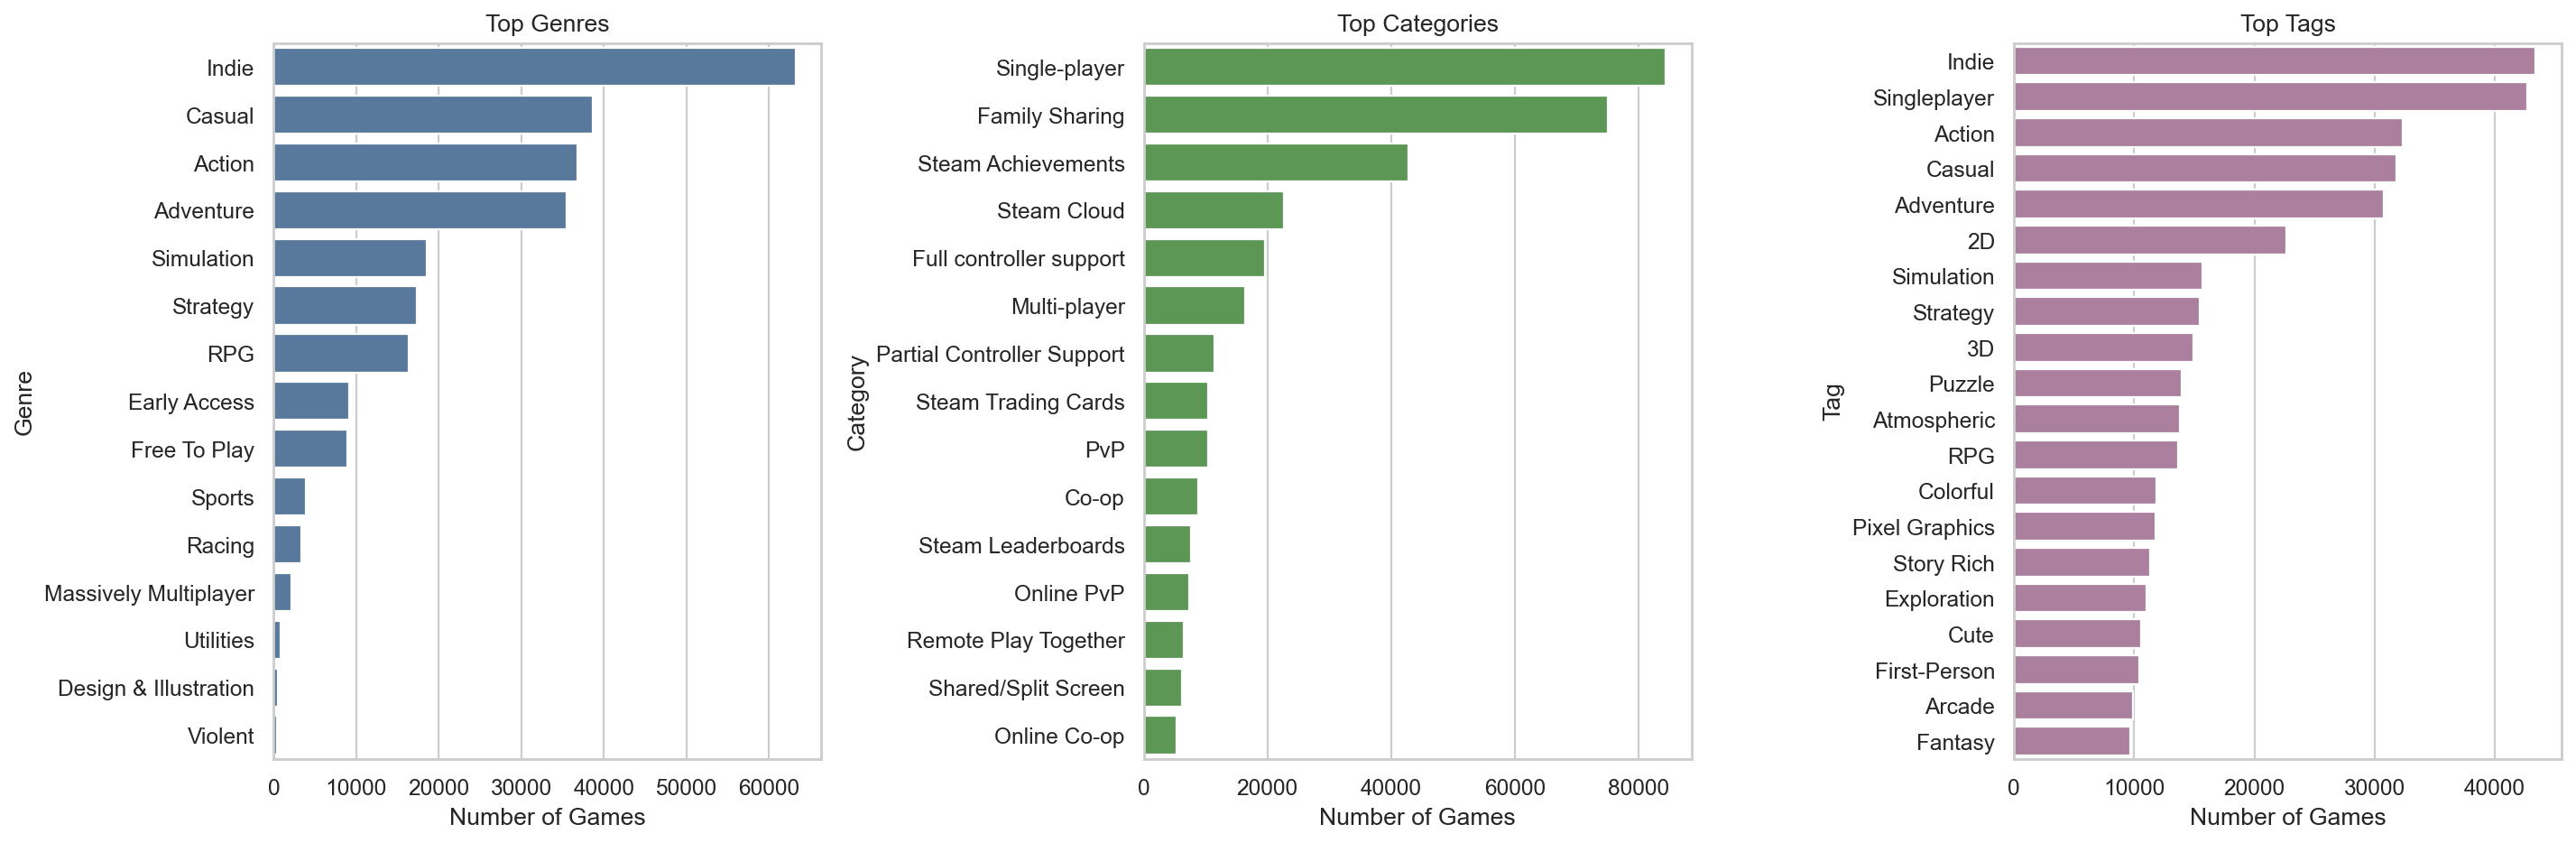

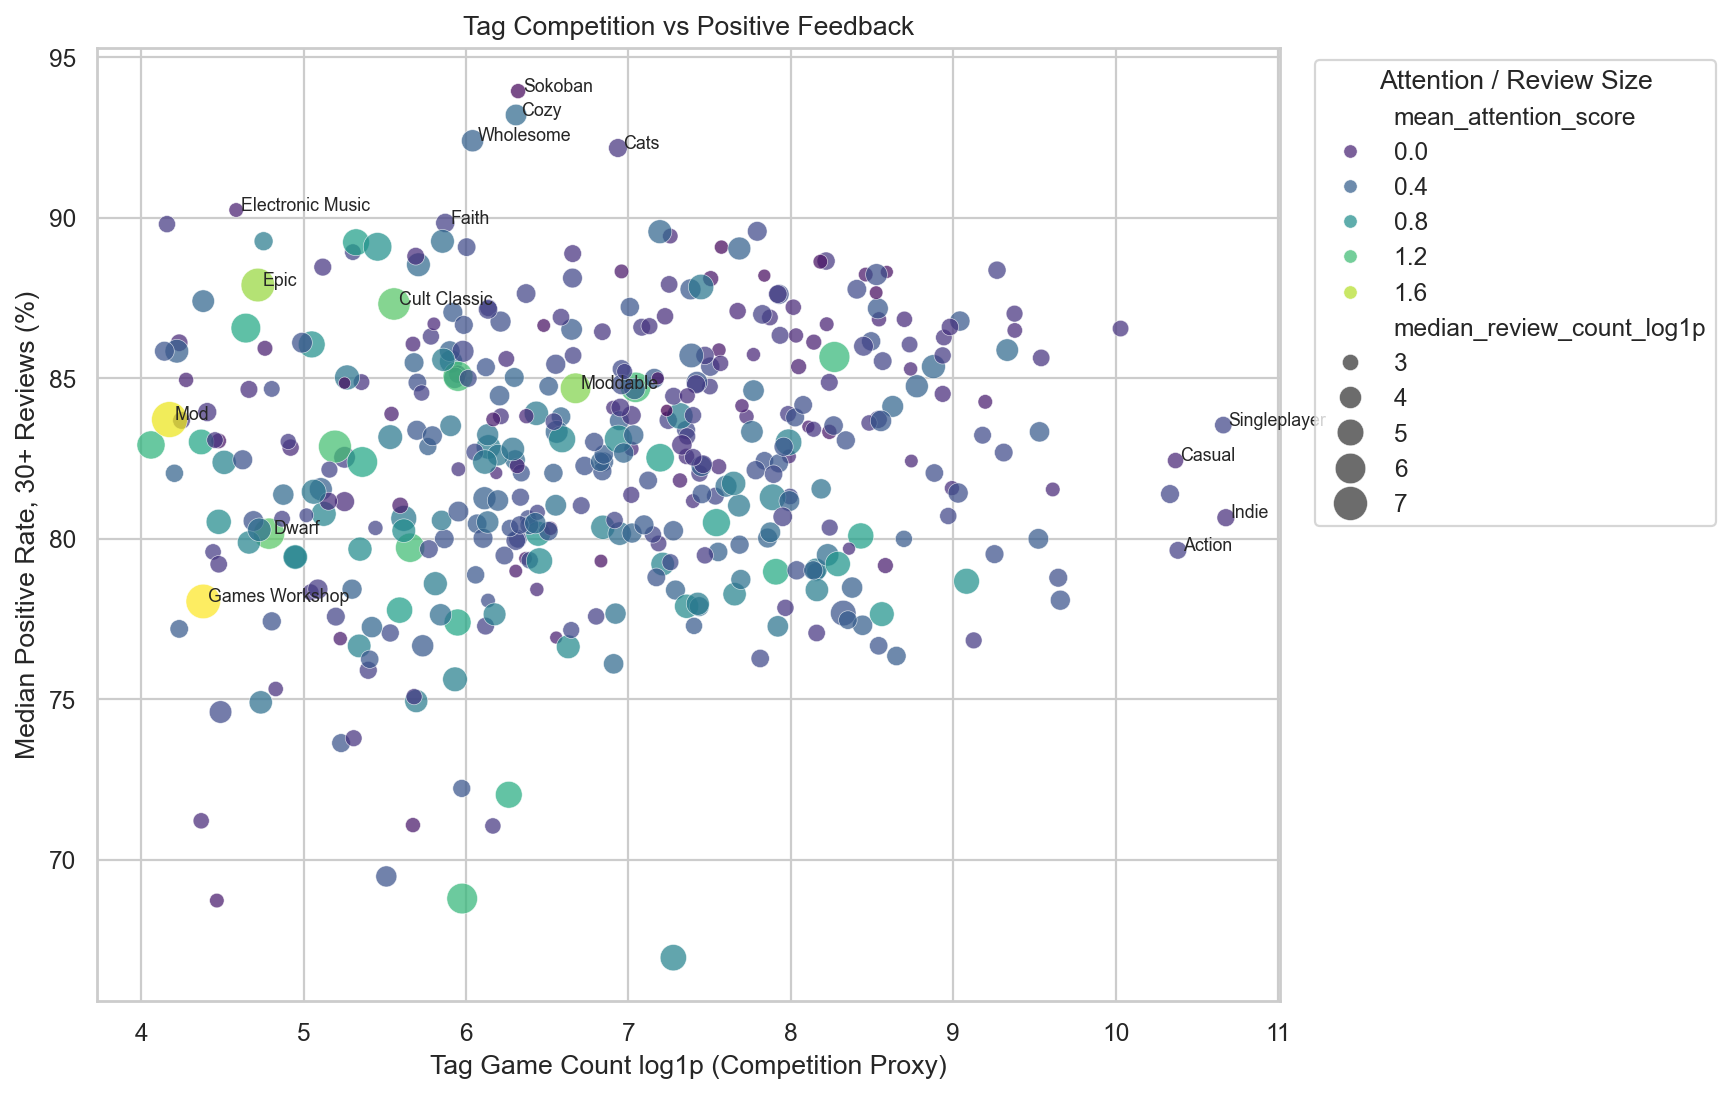

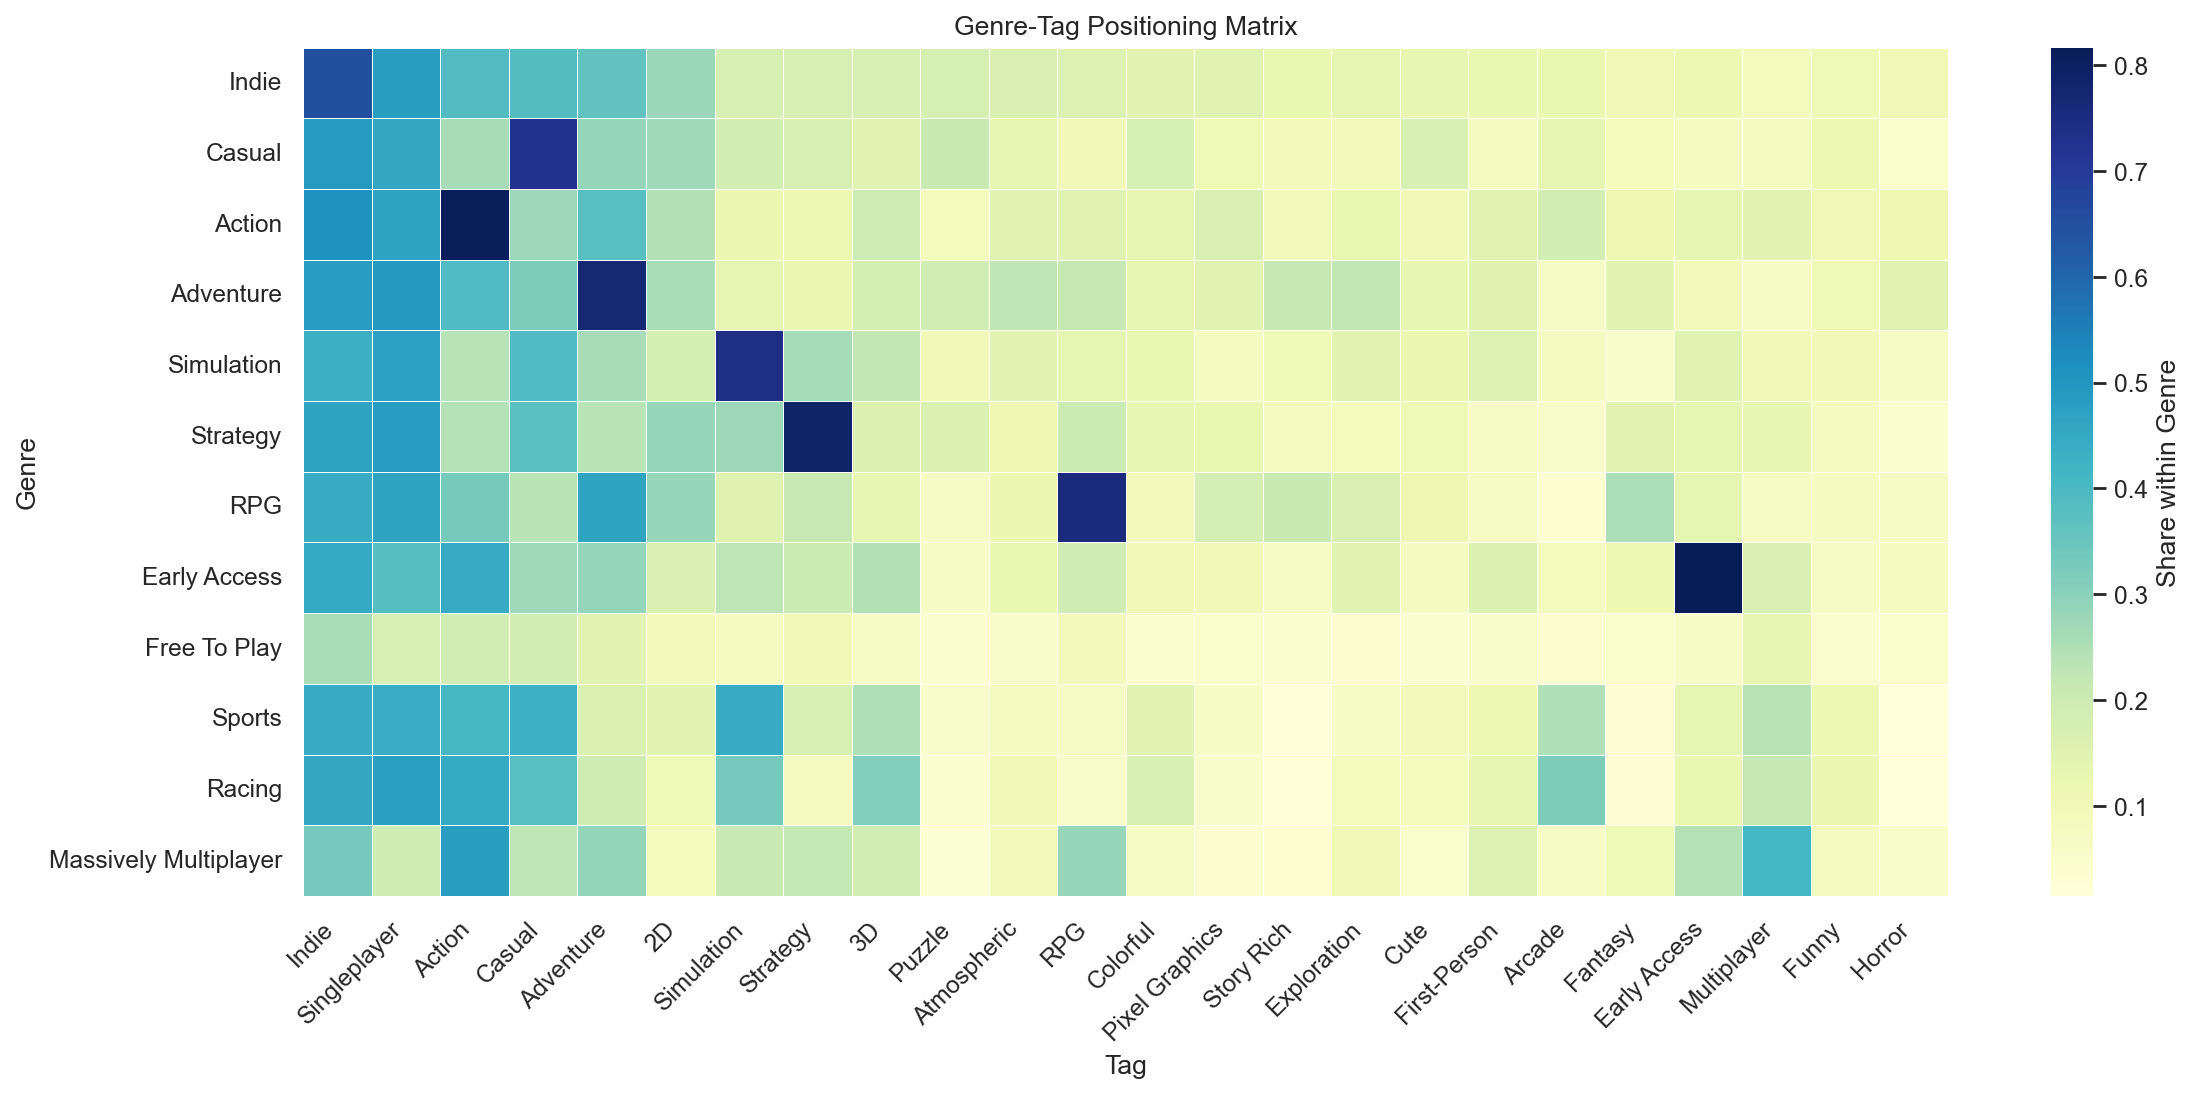

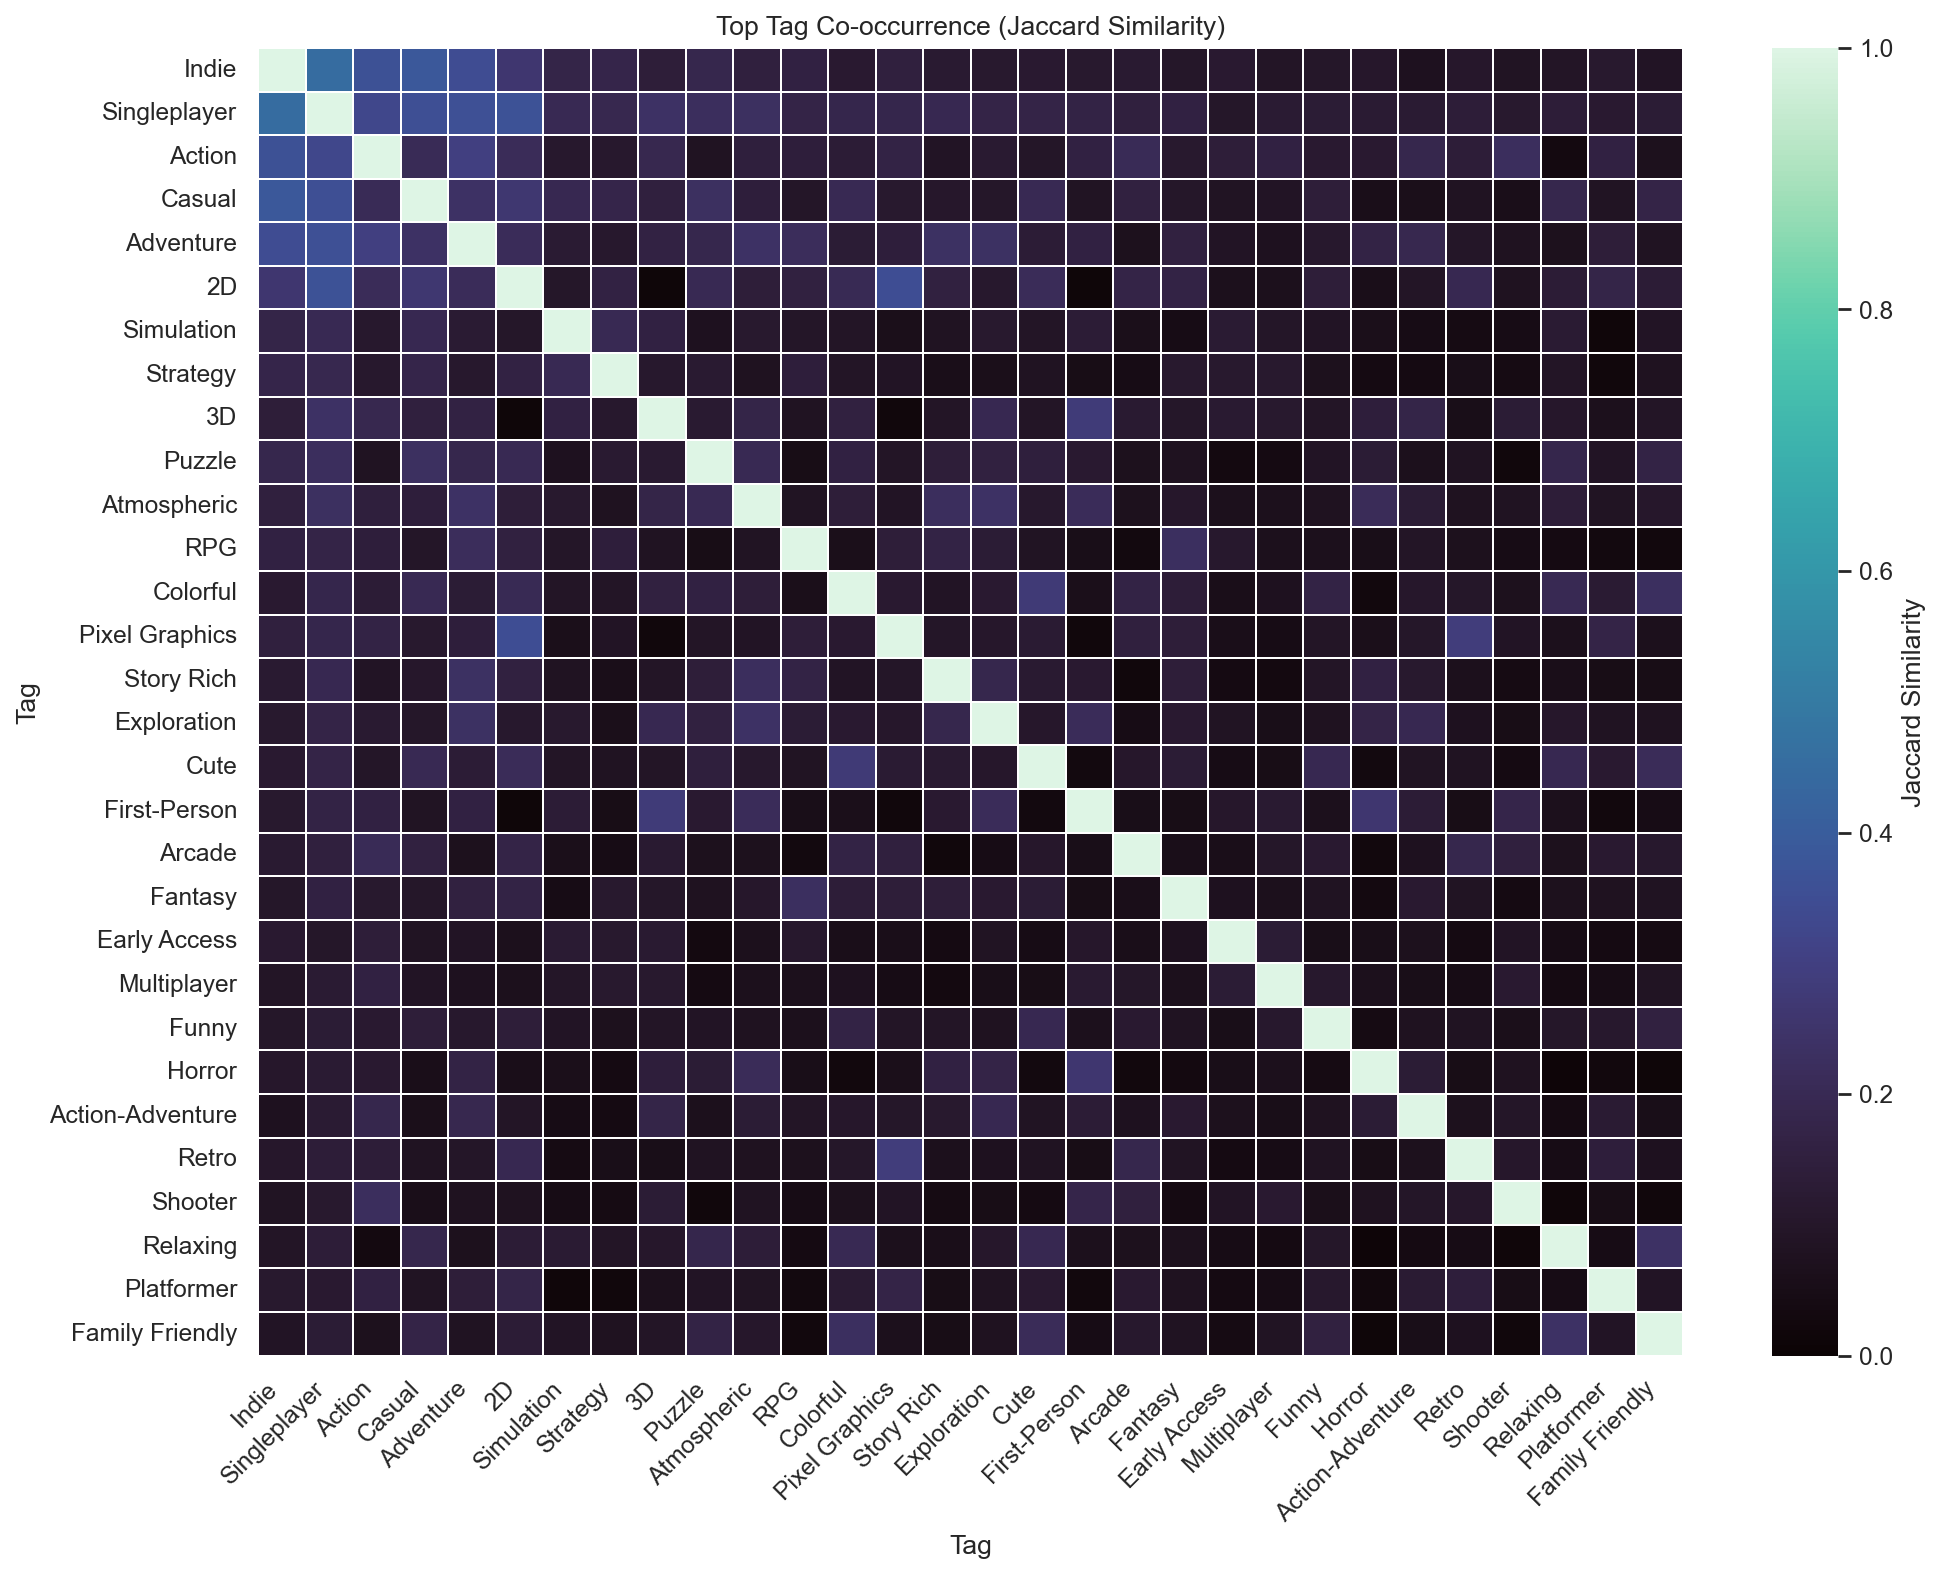

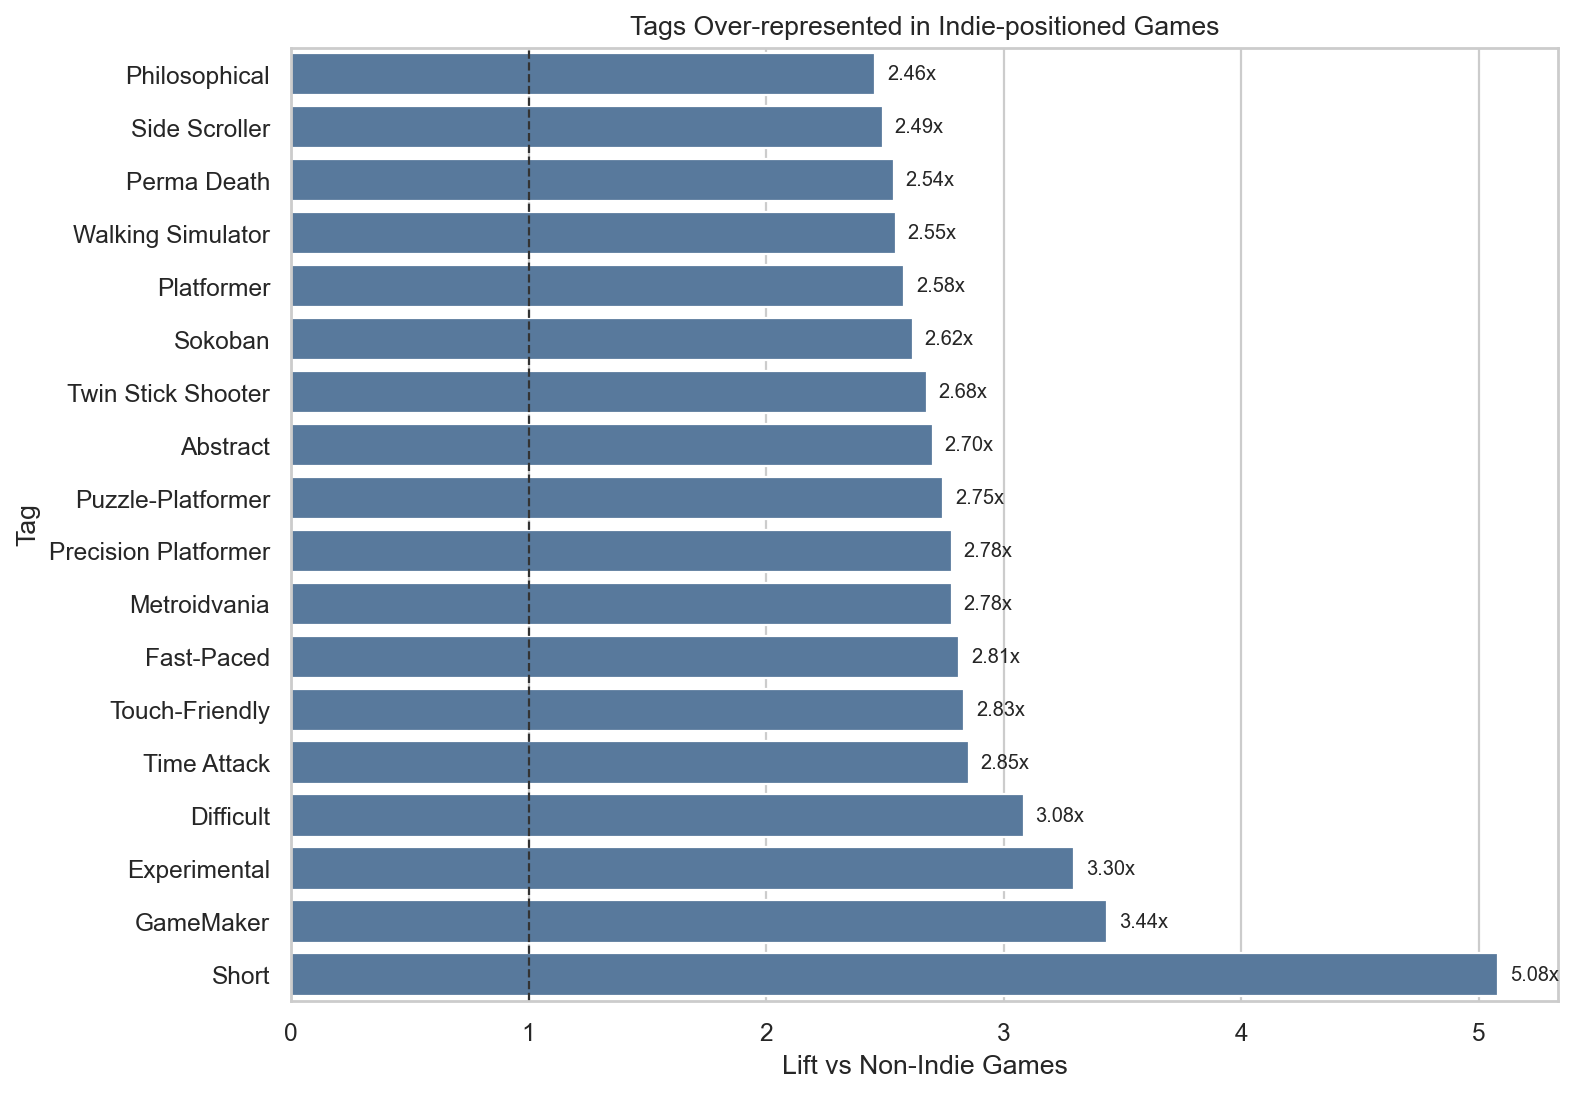

In [10]:
tag_summary_path = PROCESSED_DIR / "steam_tag_positioning_summary.csv"
niche_path = PROCESSED_DIR / "steam_tag_niche_high_feedback_candidates.csv"
cooc_path = PROCESSED_DIR / "steam_tag_cooccurrence_pairs_top.csv"
indie_path = PROCESSED_DIR / "steam_indie_tag_lift_summary.csv"

if tag_summary_path.exists():
    tag_summary = pd.read_csv(tag_summary_path)
    display(tag_summary.sort_values("game_count", ascending=False).head(10))
else:
    tag_summary = pd.DataFrame()

if niche_path.exists():
    niche_tags = pd.read_csv(niche_path)
    display(niche_tags.head(10))
else:
    niche_tags = pd.DataFrame()

if cooc_path.exists():
    cooc_pairs = pd.read_csv(cooc_path)
    display(cooc_pairs.head(10))
else:
    cooc_pairs = pd.DataFrame()

if indie_path.exists():
    indie_lift = pd.read_csv(indie_path)
    display(indie_lift.head(10))
else:
    indie_lift = pd.DataFrame()

tag_findings = pd.DataFrame([
    {"finding": "Parsed genres/categories/tags", "value": "33 genres, 40 categories, 452 tags"},
    {"finding": "Average tags per game", "value": "About 11.26"},
    {"finding": "Top genre/category/tag", "value": "Indie / Single-player / Indie"},
    {"finding": "Low-competition high-feedback candidate", "value": "Sokoban"},
    {"finding": "High descriptive-attention tag candidate", "value": "Games Workshop"},
    {"finding": "Strong top-tag co-occurrence pair", "value": "Indie + Singleplayer"},
    {"finding": "Indie lift example", "value": "Short is over-represented in Indie-positioned games"},
])
display(tag_findings)

for fig_name in [
    "31_tag_genre_category_frequency.png",
    "32_tag_competition_vs_positive_feedback.png",
    "34_genre_tag_positioning_heatmap.png",
    "35_tag_cooccurrence_jaccard_heatmap.png",
    "36_indie_tag_lift.png",
]:
    path = FIGURES_DIR / fig_name
    if path.exists():
        display(Image(filename=str(path)))

标签分析为后续推荐系统打下基础。相比只用游戏类型，标签共现和 genre-tag 矩阵更能捕捉游戏之间的相似定位；同时，评论数、好评率和热度指标可以作为推荐结果排序或过滤的辅助信息。

## 9. 综合回答研究问题

现在可以回到项目最初的两个问题。

### 问题一：什么样的 Steam 游戏更容易获得玩家关注？

从描述性结果看，玩家关注度更容易集中在少数头部游戏、部分高热度标签和具有明显市场定位的游戏上。评论数、推荐数和峰值在线人数之间存在一定关联，但它们都高度长尾；因此“玩家关注”不能只用一个指标衡量。

价格、平台数量、发行时间、类型和标签都与关注度存在某些关联，但当前分析不能证明因果关系。例如免费游戏可能降低进入门槛，多平台游戏可能增加潜在覆盖面，老游戏可能积累更多评论，但这些因素都可能同时受到开发投入、品牌、发行策略等影响。

### 问题二：Steam 市场在 2024 到 2025 之间发生了什么变化？

从两个 cleaned 快照看，March 2025 的唯一 AppID 数量高于 May 2024，说明数据中观察到的 Steam 游戏供给继续扩张。同时，总评论数也从 124,126,364 增加到 132,607,623，说明玩家反馈规模继续扩大。

但需要注意，两个快照可能存在采集口径或清洗口径差异，因此这些变化应表述为“数据集中观察到的变化”，而不是严格平台因果结论。

## 10. 方法论与课程知识点对应

为了突出课程项目价值，本节把项目工作与“大数据处理分析”课程中的常见知识点对应起来。

In [11]:
course_alignment = pd.DataFrame([
    {
        "course_topic": "AI Agent / Vibe Coding",
        "project_evidence": "使用 AI 辅助设计 Notebook 主线、生成和调试代码，但通过 nbconvert 执行验证结果。"
    },
    {
        "course_topic": "数据清洗",
        "project_evidence": "检查缺失值、重复值、异常范围、非法百分比 sentinel 值，并生成质量报告。"
    },
    {
        "course_topic": "表格数据分析",
        "project_evidence": "区分数值、类别、多标签、时间、文本字段，并按字段类型采用不同处理方式。"
    },
    {
        "course_topic": "大量级表格处理工具",
        "project_evidence": "比较 pandas、duckdb、polars 的读取、聚合和 Parquet 策略。"
    },
    {
        "course_topic": "特征工程",
        "project_evidence": "构造 release_year、game_age、platform_count、review_count、positive_rate、tag/genre count、attention score 等特征。"
    },
    {
        "course_topic": "可视化分析",
        "project_evidence": "使用分布图、折线图、甜甜圈图、散点图、热力图、长尾曲线等方式表达复杂数据。"
    },
    {
        "course_topic": "时间维度分析",
        "project_evidence": "比较 release_year 趋势和 May 2024 / March 2025 两个数据快照。"
    },
    {
        "course_topic": "结果可复现",
        "project_evidence": "每个 Notebook 都可以独立执行，生成的数据和图表路径明确，大型文件可由 Notebook 再生成。"
    },
])
display(course_alignment)

,course_topic,project_evidence
0,AI Agent / Vibe Coding,使用 AI 辅助设计 Notebook 主线、生成和调试代码，但通过 nbconvert 执...
1,数据清洗,检查缺失值、重复值、异常范围、非法百分比 sentinel 值，并生成质量报告。
2,表格数据分析,区分数值、类别、多标签、时间、文本字段，并按字段类型采用不同处理方式。
3,大量级表格处理工具,比较 pandas、duckdb、polars 的读取、聚合和 Parquet 策略。
4,特征工程,构造 release_year、game_age、platform_count、review...
5,可视化分析,使用分布图、折线图、甜甜圈图、散点图、热力图、长尾曲线等方式表达复杂数据。
6,时间维度分析,比较 release_year 趋势和 May 2024 / March 2025 两个数据快照。
7,结果可复现,每个 Notebook 都可以独立执行，生成的数据和图表路径明确，大型文件可由 Notebo...


## 11. 局限性

当前项目已经形成了较完整的数据分析链路，但仍然有几个限制需要在报告中主动说明：

1. 数据来自 Kaggle 第三方整理，字段口径依赖数据集作者，可能与 Steam 官方实时数据存在差异；
2. 当前分析主要是描述性分析，不能证明因果关系；
3. 评论数、推荐数和峰值在线人数都存在极强长尾，平均值容易被头部游戏影响；
4. 好评率在评论数很少时不稳定，因此需要设置评论数量门槛；
5. 2024 和 2025 快照对比可能受到采集时间、清洗方法和字段变化影响；
6. 标签是平台和用户共同作用下的结果，不能完全代表游戏真实内容；
7. 由于 GitHub 文件大小限制，原始数据和大型 Parquet 文件不提交，只通过下载说明和 Notebook 再生成保证可复现。

## 12. 后续方向：推荐系统但不放入主线 Notebook

项目后续可以做一个简单的 Steam 相似游戏推荐系统，但它应作为扩展，不应混入当前大数据分析主线。

推荐系统可以使用：

- `genres`、`categories`、`tags` 作为核心相似度特征；
- `short_description`、`about_the_game` 作为文本相似度补充；
- `positive_rate_calc`、`review_count_calc`、`recommendations`、`peak_ccu` 作为过滤或排序辅助；
- Notebook 06 中的标签共现和定位分析作为解释依据。

实现上可以先做轻量版本：TF-IDF + cosine similarity。为了避免只推荐头部游戏，应考虑类型相关性、标签相似度、好评率门槛和一定的多样性。

## 13. 最终报告摘要

下面生成一段可以直接放进课程报告或答辩讲稿的摘要。它不是新的分析结果，而是对前面 Notebook 的压缩总结。

In [12]:
final_summary = """
本项目以 Kaggle 的 Steam Games Dataset 2025 为数据来源，围绕“基于大规模 Steam 游戏数据的市场结构、玩家反馈与平台生态变化分析”展开。数据集包含 2024 和 2025 两个时间快照，原始 CSV 文件总量约 1.7GB，涵盖游戏基础信息、发行日期、价格、平台支持、评论、推荐、峰值在线人数、类型、标签和文本描述等字段。项目采用 Jupyter Notebook 作为主线，按数据理解、大表处理、清洗与特征工程、市场结构、玩家反馈、标签定位和报告综合七个阶段逐步展开。

在大表处理方面，项目比较了 pandas、duckdb 和 polars 的实用处理策略，并将反复使用的核心字段转换为 Parquet，以提高后续分析效率。在数据清洗与特征工程方面，项目检查了缺失值、重复值和异常范围，处理了 Steam 百分比字段中的不可用值，并构造了发行年份、游戏年龄、平台数量、评论数量、好评率、标签数量和描述性热度分数等特征。

分析结果显示，Steam 游戏市场具有明显的近年扩张和长尾结构。March 2025 cleaned 快照中包含 89,618 款游戏，2024 年是数据集中发行数量最多的年份，免费游戏占比约 15.80%，多平台游戏占比约 23.05%。玩家反馈与热度指标也高度长尾：72,563 款游戏至少有一条评论，但只有 33,358 款游戏达到 30 条及以上评论；评论数中位数为 13，而均值约为 1,479.70。对于评论数达到 30 条以上的游戏，好评率中位数约为 81.08%。

标签分析进一步说明，Steam 标签不仅是分类字段，也是一种市场定位语言。数据中解析出 33 个类型、40 个分类和 452 个标签，平均每款游戏约有 11.26 个标签。标签竞争度、好评率和热度之间并不完全一致，说明高频标签不一定代表更高反馈。标签共现、genre-tag 矩阵和 Indie 标签 lift 分析为未来构建相似游戏推荐系统提供了特征基础。

总体而言，本项目展示了如何使用 AI Agent 辅助完成一个可复现的大规模表格数据分析项目，并把复杂数据处理过程转化为课程报告中可解释、可验证的洞察。当前结果仍以描述性分析为主，不能直接说明因果关系。后续可以在此基础上继续探索 PCA、聚类、简单评分预测或基于标签与文本相似度的游戏推荐系统。
"""

display(Markdown(final_summary))

report_summary_path = REPORTS_DIR / "final_report_summary.md"
report_summary_path.write_text("# Final Report Summary\n\n" + final_summary.strip() + "\n", encoding="utf-8")
print("Saved:", report_summary_path)


本项目以 Kaggle 的 Steam Games Dataset 2025 为数据来源，围绕“基于大规模 Steam 游戏数据的市场结构、玩家反馈与平台生态变化分析”展开。数据集包含 2024 和 2025 两个时间快照，原始 CSV 文件总量约 1.7GB，涵盖游戏基础信息、发行日期、价格、平台支持、评论、推荐、峰值在线人数、类型、标签和文本描述等字段。项目采用 Jupyter Notebook 作为主线，按数据理解、大表处理、清洗与特征工程、市场结构、玩家反馈、标签定位和报告综合七个阶段逐步展开。

在大表处理方面，项目比较了 pandas、duckdb 和 polars 的实用处理策略，并将反复使用的核心字段转换为 Parquet，以提高后续分析效率。在数据清洗与特征工程方面，项目检查了缺失值、重复值和异常范围，处理了 Steam 百分比字段中的不可用值，并构造了发行年份、游戏年龄、平台数量、评论数量、好评率、标签数量和描述性热度分数等特征。

分析结果显示，Steam 游戏市场具有明显的近年扩张和长尾结构。March 2025 cleaned 快照中包含 89,618 款游戏，2024 年是数据集中发行数量最多的年份，免费游戏占比约 15.80%，多平台游戏占比约 23.05%。玩家反馈与热度指标也高度长尾：72,563 款游戏至少有一条评论，但只有 33,358 款游戏达到 30 条及以上评论；评论数中位数为 13，而均值约为 1,479.70。对于评论数达到 30 条以上的游戏，好评率中位数约为 81.08%。

标签分析进一步说明，Steam 标签不仅是分类字段，也是一种市场定位语言。数据中解析出 33 个类型、40 个分类和 452 个标签，平均每款游戏约有 11.26 个标签。标签竞争度、好评率和热度之间并不完全一致，说明高频标签不一定代表更高反馈。标签共现、genre-tag 矩阵和 Indie 标签 lift 分析为未来构建相似游戏推荐系统提供了特征基础。

总体而言，本项目展示了如何使用 AI Agent 辅助完成一个可复现的大规模表格数据分析项目，并把复杂数据处理过程转化为课程报告中可解释、可验证的洞察。当前结果仍以描述性分析为主，不能直接说明因果关系。后续可以在此基础上继续探索 PCA、聚类、简单评分预测或基于标签与文本相似度的游戏推荐系统。


Saved: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/reports/final_report_summary.md


## 14. 项目交付清单

最后确认本项目目前可以提交的内容：

- `README.md`：项目说明、数据获取方式、Notebook 顺序、GitHub 数据策略；
- `reports/project_brief.md`：项目记忆、研究问题、进度和后续方向；
- `notebooks/01` 到 `notebooks/07`：完整分析流程；
- `figures/`：报告图表；
- `data/processed/*.csv`：小型 summary 表；
- `requirements.txt`：环境依赖。

不应提交：

- `data/raw/archive/` 原始 Kaggle CSV；
- 大型压缩包；
- `data/processed/*.parquet` 大型可再生中间文件。